# Classical Chaos and Quantum Scars in the Kicked-Top System

**A Tutorial Using the Psyduck Framework**

This notebook demonstrates quantum chaos simulations using the **psyduck** library combined with custom helper functions for classical dynamics analysis.

## Overview

We explore the famous kicked-top system—a paradigmatic model of quantum chaos—where classical-quantum correspondence emerges through:
1. **Floquet analysis** of the quantum kicked-top unitary
2. **Poincaré sections** revealing classical phase space structure
3. **Quantum scars**: wave functions concentrated on classical periodic orbits

The kicked-top Hamiltonian (in the stroboscopic picture) is:

$$\mathcal{H}(t) = -\frac{\pi}{2\tau} I_y + \frac{\kappa}{p} I_z^p$$

where $I_{x,y,z}$ are angular momentum operators, $p$ is the nonlinearity order (typically 2 for quadratic), and $\kappa$ sets the chaos strength.

# Section 1: Setup and Imports

In [20]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from clyent import color

%matplotlib inline
# Add project root to path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0, project_root)

# Import psyduck framework
from psyduck import Spin
from psyduck.hamiltonians import Hz_order
from psyduck.plotting.wigner_plot import *
# Import local helper functions
import ClassicalSimFunc as cf

print("✓ All imports successful!")
print(f"QuTiP version: {qt.__version__}")


✓ All imports successful!
QuTiP version: 5.0.2


# Section 2: System Setup - Spin 3.5 Hamiltonian

We initialize a high-spin qudit system (I=3.5, corresponding to Sb-121 nuclear spin).

In [25]:
# Define spin quantum number
I = 3.5  # Spin-7/2 nucleus
dim = int(2 * I + 1)  # Hilbert space dimension = 8

# Create spin system using psyduck
nucleus = Spin(I=I)

# Get spin operators
Ix, Iy, Iz = nucleus.get_spin_operators()

print(f"✓ Initialized spin system")
print(f"  Quantum number: I = {I}")
print(f"  Hilbert space dimension: {dim}")
print(f"  Spin operators shape: {Ix.shape}")

✓ Initialized spin system
  Quantum number: I = 3.5
  Hilbert space dimension: 8
  Spin operators shape: (8, 8)


### 2.1 Kicked-Top Hamiltonian Parameters

The kicked-top Floquet operator for one period is $U_F = U_p \, U_0$, where

- **Free evolution** by a uniform rotation about $-I_y$ for time $\tau$:
$$
U_0 \;=\; \exp\!\left(-\,i\,\dfrac{\pi}{2}\,(-I_y)\,\tau\right)
\;=\; \exp\!\left(\,i\,\dfrac{\pi\,\tau}{2}\,I_y\right)
$$

- **Nonlinear kick** of order $p$ with kick strength $\kappa$ and total spin $I$:
$$
U_p \;=\; \exp\!\left(-\,i\,\dfrac{\kappa\,I_z^{\,p}}{p\,I^{\,p-1}}\right)
$$

Combined, one period of the drive advances the state by
$$
U_F \;=\; U_p\,U_0
\;=\; \exp\!\left(-\,i\,\dfrac{\kappa\,I_z^{\,p}}{p\,I^{\,p-1}}\right)\,
\exp\!\left(\,i\,\dfrac{\pi\,\tau}{2}\,I_y\right).
$$

In [26]:
# Simulation parameters
tau = 1.0              # Free evolution time between kicks (in units of pi/2)
kappa = 2.2            # Kick strength (enters chaotic regime)
order = 2              # Nonlinearity order: p=2 (quadratic)
n_kicks = 20          # Number of kicks to simulate

# Build the Floquet operator for a single period: U = U_kick @ U_free
# Free evolution Hamiltonian: H0 = (π/2τ) * (-Iy)
H_free = (np.pi / 2.0) * tau * (-Iy)
U_free = (-1j * H_free).expm()

# Nonlinear kick Hamiltonian using psyduck's Hz_order
H_kick = Hz_order(kappa, order, I)
U_kick = (-1j * H_kick).expm()

# Combined Floquet operator for one period
U_floquet = U_kick @ U_free

print(f"✓ Constructed Floquet operators")
print(f"\nParameters:")
print(f"  τ (free evolution time) = {tau}")
print(f"  κ (kick strength) = {kappa:.4f}")
print(f"  p (nonlinearity order) = {order}")
print(f"  Floquet operator shape: {U_floquet.shape}")
print(f"  Unitarity check ||U†U - I|| = {np.linalg.norm((U_floquet.dag() @ U_floquet - qt.qeye(dim)).full()):.6e}")

✓ Constructed Floquet operators

Parameters:
  τ (free evolution time) = 1.0
  κ (kick strength) = 2.2000
  p (nonlinearity order) = 2
  Floquet operator shape: (8, 8)
  Unitarity check ||U†U - I|| = 1.720653e-15


In [27]:
U_floquet

Quantum object: dims=[[8], [8]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[-0.06712203+0.05750768j -0.17758819+0.15215102j -0.30759177+0.2635333j
  -0.39709927+0.34022003j -0.39709927+0.34022003j -0.30759177+0.2635333j
  -0.17758819+0.15215102j -0.06712203+0.05750768j]
 [ 0.08966261+0.21598175j  0.16944641+0.40816714j  0.17609388+0.42417973j
   0.07577874+0.18253789j -0.07577874-0.18253789j -0.17609388-0.42417973j
  -0.16944641-0.40816714j -0.08966261-0.21598175j]
 [ 0.30792476-0.26314414j  0.34915386-0.29837741j  0.06719469-0.05742276j
  -0.26024392+0.22239739j -0.26024392+0.22239739j  0.06719469-0.05742276j
   0.34915386-0.29837741j  0.30792476-0.26314414j]
 [-0.52129925+0.04104372j -0.1970326 +0.01551307j  0.34127047-0.02686942j
   0.26434697-0.02081297j -0.26434697+0.02081297j -0.34127047+0.02686942j
   0.1970326 -0.01551307j  0.52129925-0.04104372j]
 [ 0.52129925-0.04104372j -0.1970326 +0.01551307j -0.34127047+0.02686942j
   0.26434697-0.02081297j  0.26434

# Section 3: Floquet Analysis

The one-period evolution operator $U_F$ built in Section 2 is unitary, so its full dynamical information is contained in its spectrum. We diagonalise $U_F$ once and reuse the eigenpairs throughout the rest of the notebook.

For a unitary $U_F$,
$$
U_F \, |\psi_n\rangle \;=\; \lambda_n \, |\psi_n\rangle, \qquad |\lambda_n| = 1,
$$
which means every eigenvalue sits on the complex unit circle and can be written as $\lambda_n = e^{i \omega_n}$ with **eigenphase** $\omega_n \in [0, 2\pi)$. The eigenphase plays the role of a discrete-time energy: stroboscopic evolution by $N$ kicks multiplies the $n$-th eigencomponent by $e^{i N \omega_n}$.

Section 3 is organised as
- **3.1** plot the eigenvalues on the unit circle,
- **3.2** visualise the eigenstates themselves in phase space (Wigner functions on the sphere), and
- **3.3** analyse the distribution of eigenphases, with emphasis on how the level-spacing statistics signal the regular-to-chaotic transition as $\kappa$ grows.


In [28]:
# Diagonalise the Floquet operator.  Because U_floquet is unitary, eigenstates()
# returns |lambda_n| = 1 to machine precision and unit-norm |psi_n>, so no
# extra normalisation is required.
eigvals, eigvecs = U_floquet.eigenstates()
eigvals = np.array(eigvals, dtype=complex)

# Eigenphases live in [0, 2*pi); sort everything by ascending eigenphase.
phases = np.mod(np.angle(eigvals), 2 * np.pi)
sort_idx = np.argsort(phases)

eigvals_sorted  = eigvals[sort_idx]
phases_sorted   = phases[sort_idx]
eigvecs_sorted  = [eigvecs[i] for i in sort_idx]

print(f"\n✓ Diagonalised Floquet operator on a {dim}-dimensional Hilbert space")
print(f"\nFloquet spectrum (sorted by eigenphase):")
for n, (omega, lam) in enumerate(zip(phases_sorted, eigvals_sorted)):
    print(f"  n={n}:  omega = {omega:.4f} rad,  lambda = {lam.real:+.4f} {lam.imag:+.4f}j")


✓ Diagonalised Floquet operator on a 8-dimensional Hilbert space

Floquet spectrum (sorted by eigenphase):
  n=0:  omega = 0.1525 rad,  lambda = +0.9884 +0.1520j
  n=1:  omega = 0.2766 rad,  lambda = +0.9620 +0.2731j
  n=2:  omega = 0.7861 rad,  lambda = +0.7066 +0.7076j
  n=3:  omega = 1.8474 rad,  lambda = -0.2731 +0.9620j
  n=4:  omega = 2.3569 rad,  lambda = -0.7076 +0.7066j
  n=5:  omega = 3.1803 rad,  lambda = -0.9992 -0.0387j
  n=6:  omega = 4.7511 rad,  lambda = +0.0387 -0.9992j
  n=7:  omega = 4.8649 rad,  lambda = +0.1520 -0.9884j


### 3.1 Floquet eigenvalues on the unit circle

Each eigenvalue $\lambda_n = e^{i \omega_n}$ is a point on the complex unit circle, with its angular position equal to the eigenphase $\omega_n$. Clustering or visible spacing patterns on the circle already hint at the level statistics analysed in Section 3.3.

C:\Users\z5459034\AppData\Local\Temp\ipykernel_6628\1000204385.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot(np.cos(theta_circle), np.sin(theta_circle),


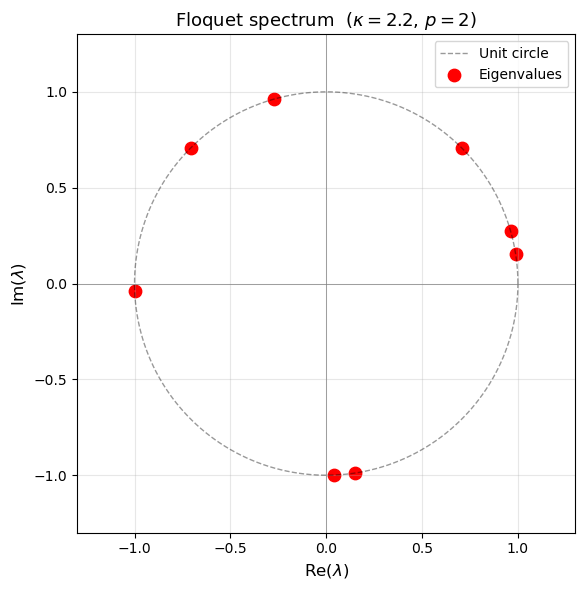

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))

# Reference unit circle
theta_circle = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(theta_circle), np.sin(theta_circle),
        'k--', alpha=0.4, lw=1, label='Unit circle', color = "black")

# Scatter the eigenvalues directly — no normalisation needed
ax.scatter(np.array(eigvals_sorted).real, np.array(eigvals_sorted).imag,
           color='red', s=80, label='Eigenvalues')

ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.grid(True, alpha=0.3)
ax.set_xlabel(r'$\mathrm{Re}(\lambda)$', fontsize=12)
ax.set_ylabel(r'$\mathrm{Im}(\lambda)$', fontsize=12)
ax.set_title(fr'Floquet spectrum  ($\kappa={kappa}$, $p={order}$)', fontsize=13)
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

### 3.2 Visualise Floquet eigenstates in phase space

Where the eigenvalue scatter shows *how often* the Floquet operator rotates an eigenstate, the Wigner function shows *where on the Bloch sphere* that eigenstate lives. Two regimes to watch for:

- **Scarred states** localise sharply along classical periodic orbits (Section 4.5). On a Hammer projection they look like narrow ridges that follow the Poincaré skeleton.
- **Ergodic / generic states** spread quasi-uniformly across the sphere and look noisy, consistent with random-matrix expectations.

The cell below plots a Hammer-projected Wigner function for every Floquet eigenstate, annotated with its eigenphase.

Plotting Wigner functions for 8 Floquet eigenstates ...


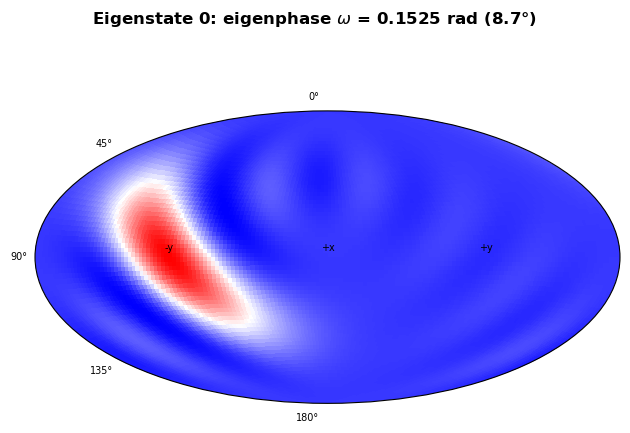

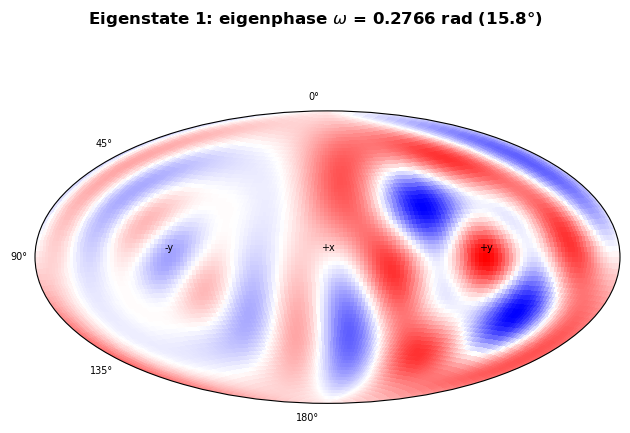

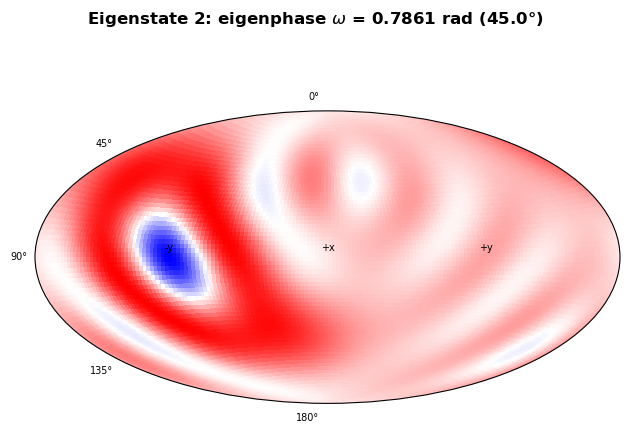

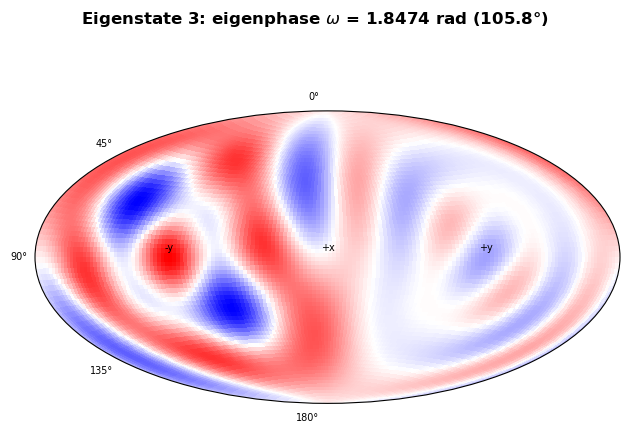

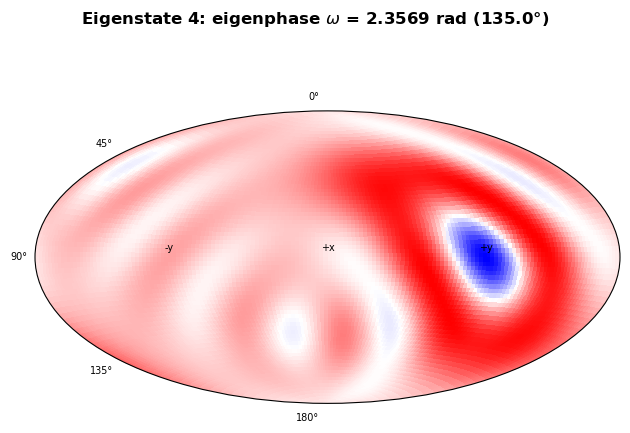

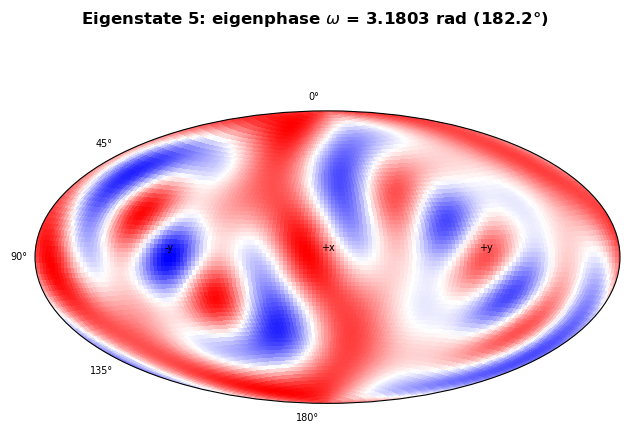

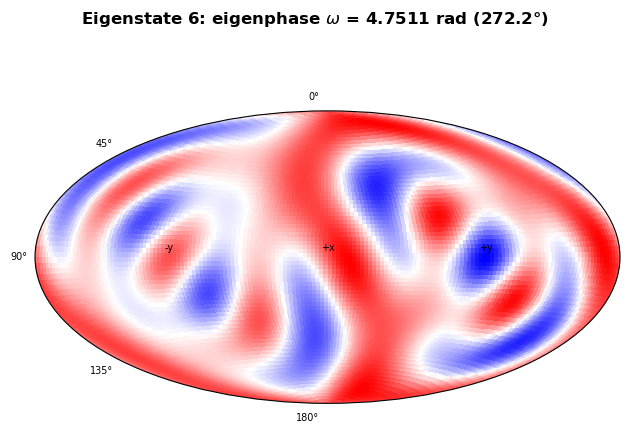

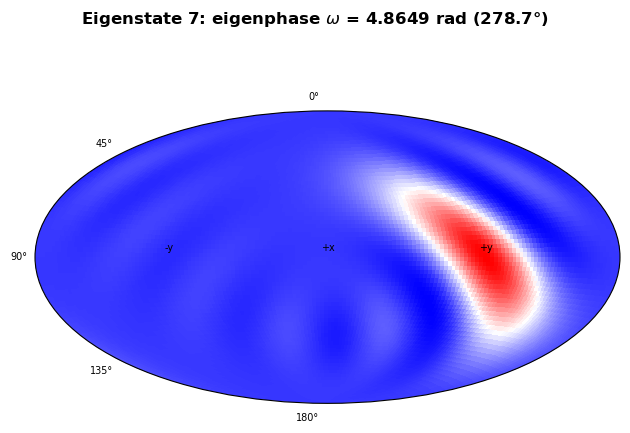


✓ Wigner functions plotted.
Interpretation:
  - Red / blue: positive / negative Wigner values
  - Narrow ridges  -> localised (candidate scar)
  - Diffuse pattern -> ergodic eigenstate


In [30]:
print(f"Plotting Wigner functions for {dim} Floquet eigenstates ...")

for i in range(dim):
    psi   = eigvecs_sorted[i]
    omega = phases_sorted[i]
    fig, ax, pcm = wigner_plot_hammer(
        psi,
        n_theta=80, n_phi=160,
        cmap='bwr', prob_function='wigner',
    )
    fig.suptitle(
        f'Eigenstate {i}: eigenphase $\\omega$ = {omega:.4f} rad '
        f'({np.degrees(omega):.1f}°)',
        fontsize=12, fontweight='bold',
    )
    plt.tight_layout()
    plt.show()

print("\n✓ Wigner functions plotted.")
print("Interpretation:")
print("  - Red / blue: positive / negative Wigner values")
print("  - Narrow ridges  -> localised (candidate scar)")
print("  - Diffuse pattern -> ergodic eigenstate")

### 3.3 Eigenphase distribution and the regular-to-chaotic transition

**Eigenphase ↔ eigenvalue.** Every Floquet eigenvalue obeys
$$
\lambda_n \;=\; e^{i \omega_n}, \qquad \omega_n \in [0, 2\pi).
$$
The eigenphase $\omega_n$ is a real number that encodes everything the modulus-1 eigenvalue carries: $\omega_n = \arg(\lambda_n)$, and conversely $\lambda_n = \cos\omega_n + i \sin\omega_n$. After $N$ stroboscopic kicks the $n$-th eigencomponent picks up the phase $e^{i N \omega_n}$, so $\omega_n$ plays the role of a dimensionless quasi-energy.

**Nearest-neighbour level spacing.** Let $\{\omega_n\}_{n=0}^{d-1}$ be the sorted eigenphases. Define the gaps
$$
\Delta\omega_n \;=\; \omega_{n+1} - \omega_n.
$$
Each $\Delta\omega_n$ carries units of **radians** (because eigenphases live on the unit circle). The dimensionless rescaled spacing is
$$
s_n \;=\; \frac{\Delta\omega_n}{\langle \Delta\omega \rangle}, \qquad \langle s \rangle = 1,
$$
which absorbs the overall density of states $\rho \equiv 1 / \langle \Delta\omega \rangle$ and leaves only the *shape* of the local-correlation distribution behind. By construction $s$ is **dimensionless** (a pure number), and $P(s)$ is a probability density with units of $1/s$ — i.e. **inverse-spacing**, also dimensionless — normalised so that $\int_0^\infty P(s)\,ds = 1$.

**What $P(s)$ reveals.** The distribution $P(s)$ is a sharp diagnostic of the underlying classical dynamics, predicted by random-matrix theory:

- **Regular (integrable) regime — Poisson statistics.**
$$
P_{\text{Poisson}}(s) \;=\; e^{-s}.
$$
Levels are statistically independent and small gaps are common: $P(s) \to 1$ as $s \to 0$. Visible as many tiny eigenphase gaps and a near-exponential histogram.

- **Chaotic regime — Wigner–Dyson (GOE) statistics.**
$$
P_{\text{GOE}}(s) \;=\; \frac{\pi}{2}\, s \, \exp\!\left(-\frac{\pi}{4} s^{2}\right).
$$
The factor of $s$ at small arguments forbids near-degeneracies — the celebrated **level repulsion** that is the spectral fingerprint of chaos. $P(0) = 0$ and the histogram peaks near $s \approx 1$.

**Effect of increasing $\kappa$.** The kicked top is integrable at $\kappa = 0$ (free rotation) and becomes increasingly chaotic as the nonlinear kick strengthens. The hand-off is visible at the level-spacing level:

1. For small $\kappa$ the Poincaré section in Section 4 is dominated by KAM tori, eigenphases come in nearly-degenerate symmetry sectors, and $P(s)$ is close to $e^{-s}$.
2. As $\kappa$ grows the regular islands shrink, the chaotic sea fills the sphere, and the small-$s$ part of $P(s)$ is pushed down — level repulsion kicks in.
3. Deep in the chaotic regime $P(s)$ matches the GOE prediction (the kicked top has a time-reversal-like symmetry, so GOE rather than GUE).

---

#### Units summary

| symbol | meaning | units |
|--------|---------|-------|
| $\omega_n$ | $n$-th eigenphase, $\omega_n = \arg(\lambda_n)$ | rad |
| $\Delta\omega_n$ | nearest-neighbour gap $\omega_{n+1} - \omega_n$ | rad |
| $\langle \Delta\omega \rangle$ | mean gap (inverse density of states) | rad |
| $s_n$ | rescaled spacing $\Delta\omega_n / \langle \Delta\omega \rangle$ | **dimensionless** |
| $P(s)$ | probability density of the rescaled spacings | dimensionless (probability per unit $s$) |

Because $s$ is dimensionless, the $\kappa = 0.1$ and $\kappa = 6$ histograms below are plotted on **identical axes** even though their underlying mean gaps $\langle\Delta\omega\rangle$ differ — the rescaling step is what makes the regular-vs-chaotic comparison meaningful at all.

---

#### Direct calculation:

The cell below carries out the most straightforward version of the calculation. For every $\kappa$ in `kappa_values` we

1. build the Floquet operator $U_F = e^{-i H_{\text{kick}}}\, U_{\text{free}}$,
2. diagonalise it directly (no symmetry reduction),
3. extract the eigenphases $\omega_n = \arg(\lambda_n) \in [0, 2\pi)$,
4. take nearest-neighbour gaps, rescale by their mean, and histogram against the Poisson and GOE reference curves.


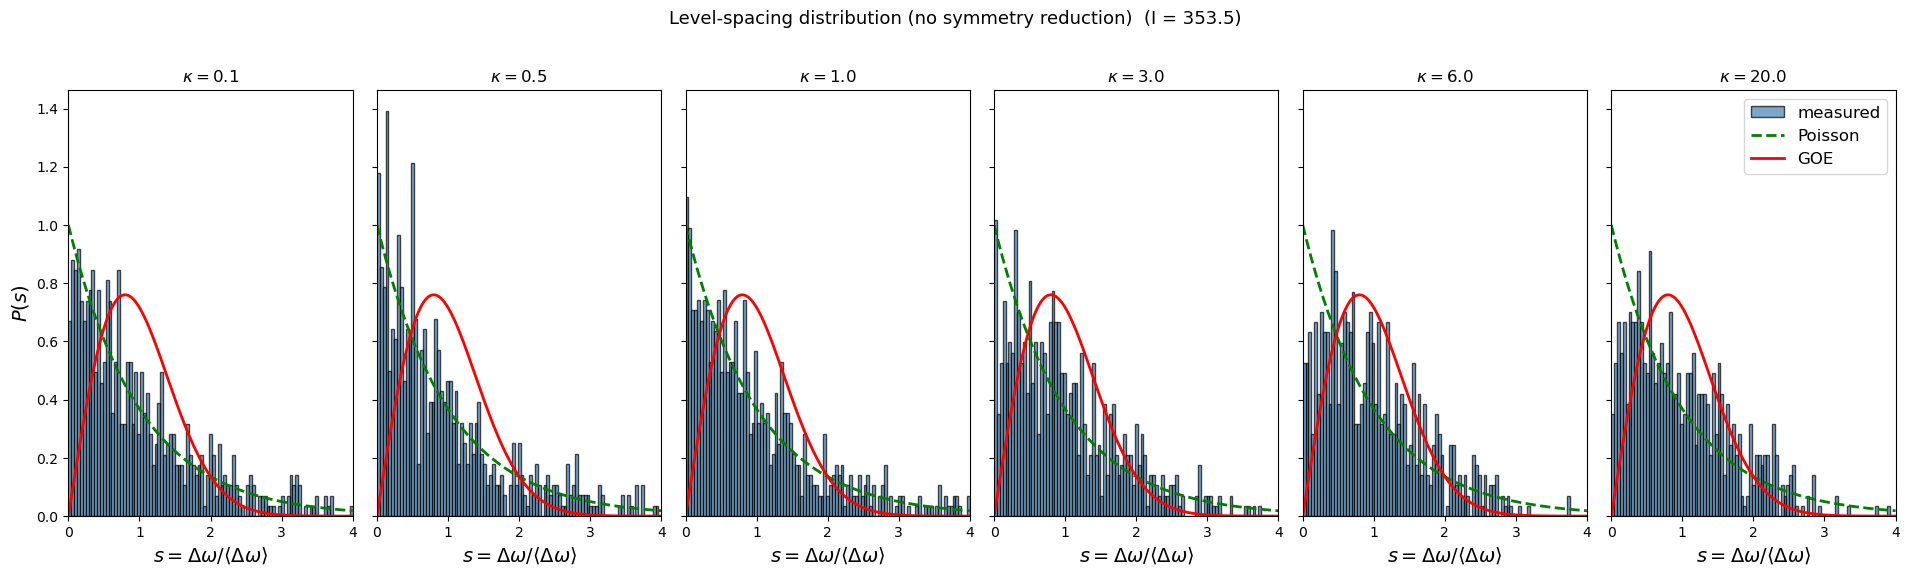

In [ ]:
# Direct, brute-force version of the level-spacing calculation: diagonalise
# the FULL Floquet operator for each kappa, take the eigenphases in one go,
# rescale by the mean spacing, and histogram.
#
# Naming convention: variables here carry the `_nt` (no-tricks) suffix so the
# spin number / period / kick order can be set independently of the parity
# cell below (whose variables use the `_lss` suffix).  Pick the same I_nt as
# I_lss if you want an apples-to-apples comparison; pick a different one if
# you want to see how the smearing changes with Hilbert dimension.

# Reference curves
s_ref     = np.linspace(0, 4, 400)
P_poisson = np.exp(-s_ref)
P_goe     = (np.pi / 2) * s_ref * np.exp(-np.pi * s_ref ** 2 / 4)

# --- Section 3.3 "no tricks" parameters (independent of every other cell) ----
I_nt     = 103.5          # spin quantum number (raise for finer histograms)
tau_nt   = 1.0            # free evolution time per period
order_nt = 2              # kick nonlinearity order

# Build spin operators locally via psyduck.
nucleus_nt = Spin(I=I_nt)
Ix_nt, Iy_nt, Iz_nt = nucleus_nt.get_spin_operators()
H_free_nt = (np.pi / 2.0) * (-Iy_nt)
U_free_nt = (-1j * H_free_nt * tau_nt).expm()
# -----------------------------------------------------------------------------
kappa_values_nt = [0.1, 0.5, 1.0, 3.0, 6.0, 20.0]   # weak -> strong driving
fig, axes = plt.subplots(1, len(kappa_values_nt), figsize=(3.2 * len(kappa_values_nt), 5.6), sharey=True)

for ax, k_val in zip(axes, kappa_values_nt):
    # Build U_F = U_kick @ U_free with the local _nt parameters.
    H_kick = Hz_order(k_val, order_nt, I_nt)
    U_F    = (-1j * H_kick).expm() @ U_free_nt

    # Direct diagonalisation of the FULL Floquet operator.
    eigvals, _ = U_F.eigenstates()
    eigvals = np.array(eigvals, dtype=complex)

    # Eigenphases in [0, 2*pi), sorted ascending.
    phases = np.sort(np.mod(np.angle(eigvals), 2 * np.pi))

    # Nearest-neighbour spacings + rescale by the mean (unfolding).
    gaps = np.diff(phases)
    s    = gaps / gaps.mean()

    ax.hist(s, bins=np.linspace(0, 4, 100), density=True,
            color='steelblue', alpha=0.7, edgecolor='black',
            label='measured')
    ax.plot(s_ref, P_poisson, 'g--', lw=2, label='Poisson')
    ax.plot(s_ref, P_goe,     'r-',  lw=2, label='GOE')
    ax.set_title(fr'$\kappa = {k_val}$')
    ax.set_xlabel(r'$s = \Delta\omega / \langle\Delta\omega\rangle$', size=14)
    ax.set_xlim(0, 4)

axes[0].set_ylabel(r'$P(s)$', size=14)
axes[-1].legend(fontsize=12, loc='upper right')
fig.suptitle(
    f'Level-spacing distribution (no symmetry reduction)  (I = {I_nt})',
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()


### 3.4 Parity-resolved level-spacing distribution

The histogram in Section 3.3 pools every eigenphase of $U_F$ into a single distribution and compares it to GOE. At large $\kappa$ the classical dynamics is fully chaotic, so each panel *should* sit on the Wigner–Dyson curve — but it doesn't. The culprit is a discrete symmetry of $U_F$ that has to be acknowledged before any random-matrix prediction can apply.

#### A parity symmetry of $U_F$

The kicked-top Floquet operator
$$U_F \;=\; e^{-i\,\kappa\,I_z^{2}/(2I)}\;e^{-i\,(\pi/2)\,I_y}$$
commutes with the **parity operator**
$$R \;=\; e^{-i\pi I_y}.$$

Two quick checks:

- $R$ is a function of $I_y$, so it trivially commutes with $e^{-i(\pi/2)I_y}$.
- A $\pi$-rotation about $y$ sends $I_z \mapsto -I_z$, so $R\,I_z^{2}\,R^{\dagger} = I_z^{2}$ and $R$ commutes with the kick.

Therefore $[U_F, R] = 0$.

#### Block decomposition of the spectrum

When two operators commute they share an eigenbasis. $R$ has only two distinct eigenvalues — $\pm 1$ for integer $I$ or $\pm i$ for half-integer $I$ — so the Hilbert space partitions cleanly into two $R$-eigenspaces,
$$\mathcal{H} \;=\; \mathcal{H}_{+} \;\oplus\; \mathcal{H}_{-}, \qquad \dim\mathcal{H}_{\pm} \;\approx\; \tfrac{1}{2}(2I+1).$$
$U_F$ preserves each one: if $R|\psi\rangle = \lambda|\psi\rangle$, then
$$R\,\bigl(U_F|\psi\rangle\bigr) \;=\; U_F\,\bigl(R|\psi\rangle\bigr) \;=\; \lambda\,\bigl(U_F|\psi\rangle\bigr),$$
so $U_F|\psi\rangle$ stays in the same eigenspace. In any orthonormal basis adapted to $R$, $U_F$ is therefore block-diagonal,
$$U_F \;=\; \begin{pmatrix} U_{+} & 0 \\ 0 & U_{-} \end{pmatrix},$$
with no matrix elements connecting the two sectors. Each $U_{\pm}$ is its own unitary on a $\sim (2I{+}1)/2$-dimensional space, and the two blocks evolve **completely independently**.

#### Why GOE only applies inside one block

The Wigner–Dyson surmise is the level-spacing distribution of a *single* random-matrix ensemble. Its signature feature — linear repulsion $P(s) \propto s$ as $s \to 0$ — is produced by the off-diagonal matrix elements that couple nearby levels. Symmetry-related levels in **different** sectors have no such coupling: $V_{+}^{\dagger}\,U_F\,V_{-} = 0$ by construction. The two blocks don't know the other exists, so there is no mechanism enforcing repulsion between a $+$-sector level and a $-$-sector level: they are free to sit arbitrarily close together.

This is the situation studied by Berry & Robnik (1984) and earlier by Rosenzweig–Porter: the level-spacing distribution of a **superposition of $N$ statistically independent spectra**. Two limits bracket the answer:

- $N = 1$: the underlying ensemble, here GOE, $P(s) = \tfrac{\pi}{2}\,s\,e^{-\pi s^{2}/4}$.
- $N \to \infty$ with equal densities: pure Poisson, $P(s) = e^{-s}$ — the classical theorem that many uncorrelated sequences look random when interleaved.

For finite $N \geq 2$ the result interpolates between the two: independent sequences contribute level pairs that don't repel, which fills in the small-$s$ region that GOE would push to zero. The kicked top sits at exactly $N = 2$ blocks of equal density $(\rho_{+} = \rho_{-} = 1/2)$, so the Section 3.3 histogram is a mixture of two GOEs. The shape that comes out — a clear $P(0) > 0$ and a peak shifted toward smaller $s$ — is the *correct* prediction for that mixture; it just isn't GOE. To recover GOE we have to histogram each sector separately, or pool only after unfolding.

#### Orthonormal basis from $I_y$

To project $U_F$ onto a sector we need orthonormal column matrices $V_{\pm}$ whose columns span $\mathcal{H}_{\pm}$. Because $R$ is a function of $I_y$, any eigenbasis of $I_y$ is automatically an eigenbasis of $R$:
$$R\,|m_y\rangle \;=\; e^{-i\pi m_y}\,|m_y\rangle.$$
That eigenvalue flips sign every time $m_y$ increments by $1$, so adjacent $m_y$ states sit in **opposite** sectors:

| sector | $m_y$ values |
|---|---|
| $+$ | $m_{y,\text{min}},\ m_{y,\text{min}}{+}2,\ m_{y,\text{min}}{+}4,\ \ldots$ |
| $-$ | $m_{y,\text{min}}{+}1,\ m_{y,\text{min}}{+}3,\ m_{y,\text{min}}{+}5,\ \ldots$ |

$I_y$ is hermitian, so `Iy_nt.eigenstates()` returns orthonormal eigenvectors via `eigh`. The sector label is the parity of the integer offset $k = m_y - m_{y,\text{min}}$, which is an integer for both integer and half-integer $I$ — the same code path handles either.

Two diagnostics confirm we have the right basis:

- $\lVert V^{\dagger}V - \mathbb{1}\rVert \approx 0$: the $V_{\pm}$ columns are orthonormal.
- $\lVert V_{+}^{\dagger}\,U_F\,V_{-}\rVert \approx 0$: $U_F$ really is block-diagonal here.

#### Pipeline

1. Diagonalise $I_y$ and split its basis into $V_{+}, V_{-}$ by the parity of $k$.
2. For each $\kappa$, form $U_{\pm} = V_{\pm}^{\dagger}\,U_F\,V_{\pm}$, diagonalise each block, and read off the eigenphases $\omega_n^{(\pm)} \in [0, 2\pi)$.
3. Sort each sector's phases, take nearest-neighbour gaps $\Delta\omega_n^{(\pm)} = \omega_{n+1}^{(\pm)} - \omega_n^{(\pm)}$, and **unfold each sector by its own mean** $s_n^{(\pm)} = \Delta\omega_n^{(\pm)} / \langle\Delta\omega^{(\pm)}\rangle$.
4. Concatenate the dimensionless $s$ values from both sectors and histogram against the GOE and Poisson reference curves.

At large $\kappa$ the histogram now collapses onto the GOE curve. Residual roughness is finite-size noise — $\sim\!104$ levels per sector at $I = 103.5$ — and shrinks with larger `I_nt`.


Parity sector dimensions: + = 104,  - = 104
Orthonormality ||V^dag V - I||         = 6.41e-13
Off-diagonal block ||V_+^dag U_F V_-|| = 5.11e-13


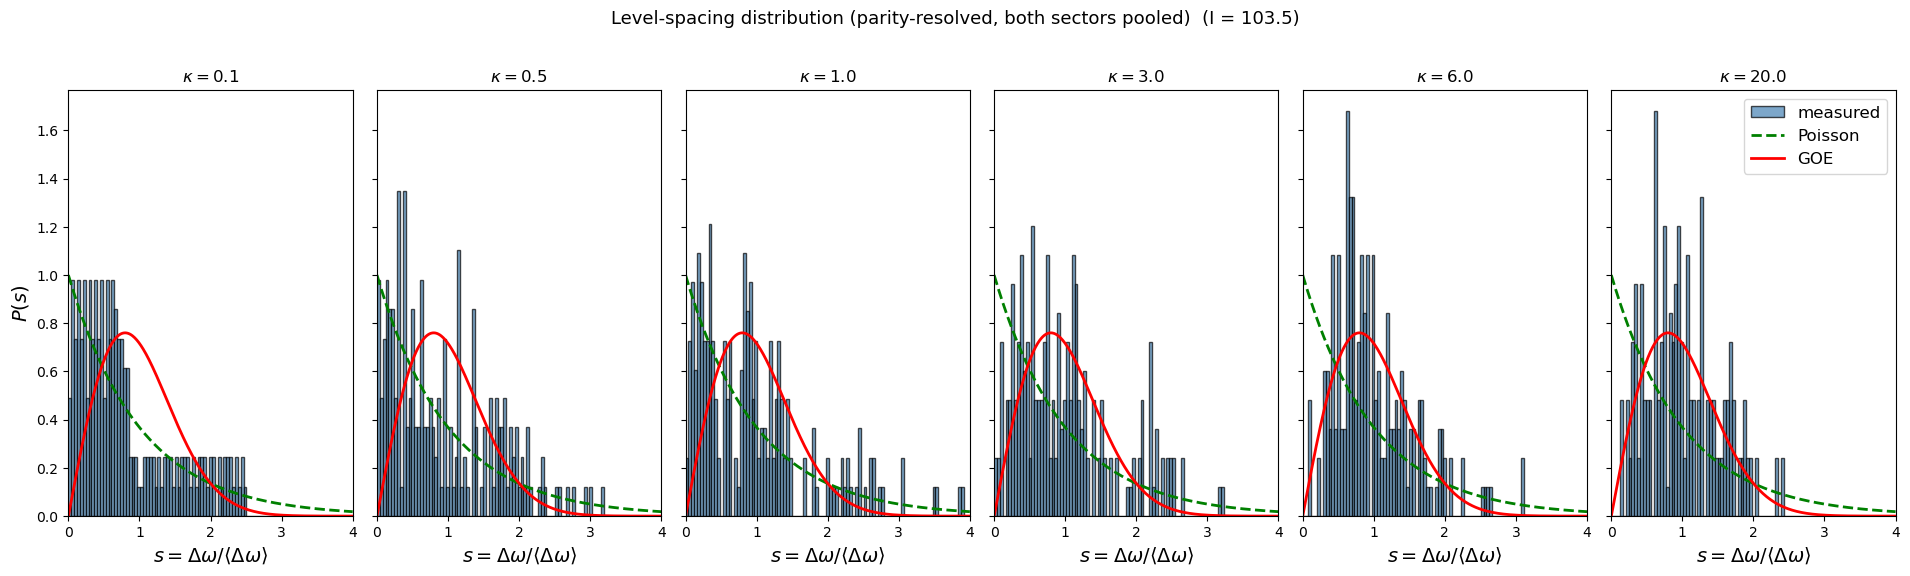

In [59]:
Iy_evals, Iy_evecs = Iy_nt.eigenstates()
my_vals = np.real(np.array(Iy_evals))

m_idx = np.round(my_vals - my_vals[0]).astype(int)
plus_mask = (m_idx % 2 == 0)

V_plus  = np.column_stack([v.full().ravel() for v, m in zip(Iy_evecs, plus_mask) if m])
V_minus = np.column_stack([v.full().ravel() for v, m in zip(Iy_evecs, plus_mask) if not m])

V_all  = np.column_stack([V_plus, V_minus])
ortho_resid = np.linalg.norm(V_all.conj().T @ V_all - np.eye(V_all.shape[1]))
U_F_probe = ((-1j * Hz_order(2.0, order_nt, I_nt)).expm() @ U_free_nt).full()
block_resid = np.linalg.norm(V_plus.conj().T @ U_F_probe @ V_minus)
print(f"Parity sector dimensions: + = {V_plus.shape[1]},  - = {V_minus.shape[1]}")
print(f"Orthonormality ||V^dag V - I||         = {ortho_resid:.2e}")
print(f"Off-diagonal block ||V_+^dag U_F V_-|| = {block_resid:.2e}")


def sector_spacings(U_full_np, V):
    U_blk  = V.conj().T @ U_full_np @ V
    phases = np.sort(np.mod(np.angle(np.linalg.eigvals(U_blk)), 2 * np.pi))
    gaps   = np.diff(phases)
    return gaps / gaps.mean()


fig, axes = plt.subplots(1, len(kappa_values_nt),
                         figsize=(3.2 * len(kappa_values_nt), 5.6), sharey=True)

for ax, k_val in zip(axes, kappa_values_nt):
    H_kick = Hz_order(k_val, order_nt, I_nt)
    U_F_np = ((-1j * H_kick).expm() @ U_free_nt).full()

    s = np.concatenate([sector_spacings(U_F_np, V_plus),
                        sector_spacings(U_F_np, V_minus)])

    ax.hist(s, bins=np.linspace(0, 4, 100), density=True,
            color='steelblue', alpha=0.7, edgecolor='black',
            label='measured')
    ax.plot(s_ref, P_poisson, 'g--', lw=2, label='Poisson')
    ax.plot(s_ref, P_goe,     'r-',  lw=2, label='GOE')
    ax.set_title(fr'$\kappa = {k_val}$')
    ax.set_xlabel(r'$s = \Delta\omega / \langle\Delta\omega\rangle$', size=14)
    ax.set_xlim(0, 4)

axes[0].set_ylabel(r'$P(s)$', size=14)
axes[-1].legend(fontsize=12, loc='upper right')
fig.suptitle(
    f'Level-spacing distribution (parity-resolved, both sectors pooled)  (I = {I_nt})',
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()


# Section 4: Classical Phase Space - Poincaré Sections

## What a Poincaré map is

The kicked top is a periodically driven Hamiltonian system. Its classical state lives on the Bloch sphere as a unit vector
$$\mathbf{v} = (x, y, z), \qquad |\mathbf{v}| = 1,$$
or equivalently a pair of spherical angles $(\theta, \phi)$. Because the drive is periodic, the natural way to look at the dynamics is **stroboscopically**: instead of recording $\mathbf{v}(t)$ continuously, we snapshot the system once per drive period, immediately after each complete kick cycle. The stroboscopic snapshots form a **Poincaré section** — a discrete picture of the underlying continuous flow that exposes its long-time structure without the clutter of the within-period transients.

One drive period acts on the sphere as a discrete map
$$\mathbf{v}_{n+1} = F(\mathbf{v}_n),$$
where $F$ consists of two exact rotations:
1. A nonlinear $z$-twist by angle $-\kappa\,\mathrm{sgn}(z)\,|z|^{p-1}$.
2. A rigid $y$-rotation by angle $-\alpha$ (here $\alpha = \pi/2$, matching the quantum Floquet operator).

Iterating $F$ from a grid of initial conditions traces out the classical phase portrait. Interpreting the resulting scatter:

- **Smooth closed curves** → regular (quasi-periodic) motion on invariant tori.
- **Dense 2-D clouds** → chaotic motion exploring an ergodic region.
- **Empty gaps / island chains** → stable orbits embedded in chaos.
- **Isolated repeating points** → low-period orbits.

## How the code generates the map

We use the `psyduck`-adjacent helper module `cf = ClassicalSimFunc`. The pipeline below is repeated, with minor variations, throughout the section:

1. **Build a seed grid** of `n_seeds_phi × n_seeds_theta` initial conditions on the sphere via `cf.sph_to_cart(theta, phi)`.
2. **Iterate the map** `cf.kicked_top_step(v, kappa, alpha, order)` for `n_iter` steps on every seed in parallel.
3. **Discard the first `n_discard` iterates** — early points still reflect the arbitrary grid, not the invariant structure.
4. **Convert back to angles** with `cf.spherical_angles(v)` and stack into `phi_arr`, `theta_arr` of shape `(n_iter - n_discard, n_seeds)`.
5. **Scatter-plot** the flattened arrays. With the defaults used in Section 4.1 (12×12 seeds, 1500 iterations, 100 discarded) every plot draws $12 \times 12 \times 1400 = 201{,}600$ deterministic stroboscopic samples.

## 4.1 Static Poincaré map

Reuse the kicked-top parameters from Section 2 (`kappa`, `order`) plus the classical free-rotation angle `alpha = π/2`. Generate the seed grid, iterate the map, and scatter the resulting points on the $(\phi, \theta)$ plane.

In [ ]:
# Classical-side parameters reuse the quantum Section 2 values
alpha = np.pi / 2          # classical rotation angle (matches tau = 1 in Section 2)

# Seed grid + iteration budget
n_seeds_phi   = 12
n_seeds_theta = 12
n_iter        = 1500
n_discard     = 100

phis_seed   = np.linspace(-np.pi, np.pi, n_seeds_phi, endpoint=False)
thetas_seed = np.linspace(0.15 * np.pi, 0.85 * np.pi, n_seeds_theta)

seeds_cart, seeds_theta0, seeds_phi0 = [], [], []
for th in thetas_seed:
    for ph in phis_seed:
        seeds_cart.append(cf.sph_to_cart(th, ph))
        seeds_theta0.append(th)
        seeds_phi0.append(ph)
v = np.stack(seeds_cart, axis=0)
seeds_theta0 = np.asarray(seeds_theta0)
seeds_phi0   = np.asarray(seeds_phi0)
n_seeds = v.shape[0]

# Iterate and record post-discard angles
n_keep    = n_iter - n_discard
phi_arr   = np.empty((n_keep, n_seeds))
theta_arr = np.empty((n_keep, n_seeds))

for i in range(n_iter):
    v = cf.kicked_top_step(v, kappa, alpha, order)
    if i >= n_discard:
        phi_arr[i - n_discard], theta_arr[i - n_discard] = cf.spherical_angles(v)

# Flatten once for plotting (also used by later sections)
phi_pts   = phi_arr.ravel()
theta_pts = theta_arr.ravel()

# Static black-and-white Poincaré section
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor('black')
ax.scatter(phi_pts, theta_pts, c='white', s=0.4, alpha=0.6)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(np.pi, 0)            # θ=0 at top (north pole up)
ax.set_xlabel(r'$\phi$ (azimuthal angle)', fontsize=12)
ax.set_ylabel(r'$\theta$ (polar angle)',   fontsize=12)
ax.set_title(f'Poincaré section  (κ={kappa}, p={order}, α=π/2)', fontsize=13)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
ax.set_yticks([0, np.pi/2, np.pi])
ax.set_yticklabels([r'$0$', r'$\pi/2$', r'$\pi$'])
ax.grid(True, alpha=0.3, linestyle=':')
plt.tight_layout()
plt.show()

print(f"✓ Plotted {phi_pts.size:,} stroboscopic points "
      f"({n_seeds} seeds × {n_keep} iterates).")

## 4.2 Colored Poincaré map by seed origin

Coloring each plotted point by its seed's starting position turns the static scatter into a much more informative picture: trajectories from neighbouring seeds inherit similar colours, so KAM tori stay monochromatic while chaotic seas mix every colour together. The colour itself is a diagonal gradient over $(\theta_0, \phi_0)$, previewed below.

In [ ]:
# Diagonal gradient preview (the colormap that will label each seed)
n = 256
x = np.linspace(0, 1, n)
y = np.linspace(0, 1, n)
X, Y = np.meshgrid(x, y)

gradient = (X + Y) / 2  # diagonal: top-left → bottom-right

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(gradient, cmap='nipy_spectral', origin='lower', extent=[0, 1, 0, 1])
ax.set_xlabel(r'$(\phi_0 + \pi) / 2\pi$')
ax.set_ylabel(r'$\theta_0 / \pi$')
ax.set_title('Seed-position colormap (nipy_spectral)')
plt.tight_layout()
plt.show()

In [ ]:
# Per-seed colour: diagonal gradient on the seed grid (in [0, 2])
c_seed    = (seeds_theta0 / np.pi) + ((seeds_phi0 + np.pi) / (2 * np.pi))
color_arr = np.broadcast_to(c_seed, phi_arr.shape)

# Choose the projection: 'rectangular' (φ vs θ) or 'hammer' (equal-area sphere)
projection = 'rectangular'   # 'rectangular' or 'hammer'
cmap       = 'nipy_spectral'

if projection == 'rectangular':
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(phi_arr.ravel(), theta_arr.ravel(),
                    c=color_arr.ravel(), cmap=cmap, s=0.5, alpha=0.5)
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(np.pi, 0)
    ax.set_xlabel(r'$\phi$ (azimuthal angle)', fontsize=12)
    ax.set_ylabel(r'$\theta$ (polar angle)',   fontsize=12)
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
    ax.set_yticks([0, np.pi/2, np.pi])
    ax.set_yticklabels([r'$0$', r'$\pi/2$', r'$\pi$'])
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.set_title(f'Poincaré section coloured by seed  (κ={kappa}, p={order})',
                 fontsize=13)
    cbar = plt.colorbar(sc, ax=ax)
elif projection == 'hammer':
    lon = phi_arr.ravel()                    # in [-π, π]
    lat = np.pi / 2 - theta_arr.ravel()      # θ ∈ [0, π] → lat ∈ [π/2, -π/2]

    fig = plt.figure(figsize=(10, 5))
    ax  = fig.add_subplot(111, projection='hammer')
    sc  = ax.scatter(lon, lat, c=color_arr.ravel(), cmap=cmap,
                     s=0.5, alpha=0.5)
    ax.set_xticks([])
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.set_title(f'Poincaré section (Hammer)  (κ={kappa}, p={order})',
                 fontsize=13, pad=20)
    cbar = plt.colorbar(sc, ax=ax, orientation='horizontal',
                        fraction=0.05, pad=0.08, shrink=0.7)
else:
    raise ValueError(f"projection must be 'rectangular' or 'hammer', got {projection!r}")

cbar.set_label('Seed diagonal coordinate', fontsize=10)
plt.tight_layout()
plt.show()

## 4.3 Animate over a parameter sweep

Re-running the kicked-top map for many values of $\kappa$ (or $\alpha$) and stacking the resulting Poincaré sections into a GIF is the classical analogue of watching the eigenstate landscape evolve as the drive strength changes. The cell below sweeps `kappa` from 0.1 to 4.0 by default; toggle `sweep_param = 'alpha'` to sweep the free-rotation angle instead, and `projection` between `'hammer'` and `'rectangular'`.

In [ ]:
import io
from PIL import Image
from IPython.display import Image as IPyImage, display

# --- sweep configuration -------------------------------------------------
sweep_param  = 'kappa'                       # 'kappa' or 'alpha'
kappa_sweep  = np.linspace(0.1, 4.0, 50)
alpha_sweep  = np.linspace(0.1, np.pi, 30)
fixed_kappa  = kappa
fixed_alpha  = alpha
projection   = 'rectangular'                 # 'rectangular' or 'hammer'

n_iter_anim    = 600
n_discard_anim = 50
anim_cmap      = 'nipy_spectral'
filename       = f'kicked_top_sweep_{projection}.gif'
fps, dpi       = 5, 100
# -------------------------------------------------------------------------

sweep_vals = kappa_sweep if sweep_param == 'kappa' else alpha_sweep

# Reusable seed grid (cheap, depends only on n_seeds_phi/theta)
seeds_cart_a = np.stack([cf.sph_to_cart(th, ph)
                          for th in thetas_seed for ph in phis_seed], axis=0)
seeds_th0_a  = np.repeat(thetas_seed, n_seeds_phi)
seeds_ph0_a  = np.tile(phis_seed, n_seeds_theta)
n_seeds_a    = seeds_cart_a.shape[0]
c_seed_a     = (seeds_th0_a / np.pi) + ((seeds_ph0_a + np.pi) / (2 * np.pi))

frames = []
for k, val in enumerate(sweep_vals):
    if sweep_param == 'kappa':
        kappa_val, alpha_val = val, fixed_alpha
    else:
        kappa_val, alpha_val = fixed_kappa, val
    label = fr'$\kappa$={kappa_val:.2f},  $\alpha$={alpha_val:.2f}'

    # Trajectory iteration + Poincare-axis setup now live in ClassicalSimFunc.
    phi_a, theta_a = cf.iterate_kicked_top(
        seeds_cart_a, kappa_val, alpha_val, order,
        n_iter=n_iter_anim, n_discard=n_discard_anim,
    )
    if projection == 'hammer':
        x = phi_a.ravel()
        y = np.pi / 2 - theta_a.ravel()
    else:
        x = phi_a.ravel()
        y = theta_a.ravel()
    col = np.broadcast_to(c_seed_a, phi_a.shape).ravel()

    fig = plt.figure(figsize=(8, 4.5))
    ax  = cf.make_poincare_axes(fig, projection=projection)
    ax.scatter(x, y, c=col, cmap=anim_cmap, s=0.4, alpha=0.5,
               vmin=c_seed_a.min(), vmax=c_seed_a.max())
    ax.set_title(f'Poincare section ({projection}) - {label}',
                 fontsize=12, pad=15)

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight')
    buf.seek(0)
    frames.append(Image.open(buf).copy())
    plt.close(fig)
    print(f'  frame {k + 1:>3}/{len(sweep_vals)}  {label}')

frames[0].save(
    filename,
    save_all=True,
    append_images=frames[1:],
    loop=0,
    duration=int(1000 / fps),
)
print(f'\nSaved {filename}  ({len(frames)} frames @ {fps} fps)')
display(IPyImage(filename=filename))

## 4.4 Phase-space diagnostics, zoom, and 3-D visualisations

The cells below organise the standalone scripts in `examples/ChaosQKT/classical/` into the notebook. Each cell is independent and runs against the trajectory arrays computed in Section 4.1 unless it re-runs its own simulation.

| Cell | What it does | Source script |
|------|--------------|---------------|
| 4.4.1 | Orbital-period classification (recurrence + PCA aspect) | `color_plot.py` |
| 4.4.2 | Maximal Lyapunov exponent per seed | `color_plot.py` |
| 4.4.3 | 2-D histogram of trajectory density | `color_plot.py` |
| 4.4.4 | Zoomed Poincaré section with seed-density auto-scaling | `color_plot_zoomed.py` |
| 4.4.5 | 3-D spinning sphere (static parameters) | `color_plot_3d_spin.py` |
| 4.4.6 | 3-D spinning sphere with parameter sweep | `color_3d_spin_anim.py` |

In [ ]:
# 4.4.1 - Orbital period classification
#
# Goal: assign every seed a label - "period-p", "quasi-periodic", or "chaotic" -
# by looking at the trajectory it generates, then recolor the Poincare section
# by those labels. This converts the qualitative "smooth curve vs. fuzzy cloud"
# distinction from Section 4.1 into a quantitative classification.
#
# Two tests are combined:
#   (a) RECURRENCE  - if v[i+p] is geodesically close to v[i] for some small p,
#       the orbit is period-p. We sweep p = 1..max_p and stop at the first hit.
#   (b) PCA ASPECT  - the trajectory of one seed is a cloud in R^3. PCA gives
#       the cloud's two largest variances lambda_1 >= lambda_2. Ratio lambda_2/lambda_1
#       is ~0 for a 1-D curve (quasi-periodic on a torus) and ~1 for a 2-D
#       filled region (chaotic). The threshold aspect_thresh separates the two.
#
# Final code per seed:
#   period_code = p > 0  -> true period-p orbit
#                 0      -> quasi-periodic (smooth curve, no exact recurrence)
#                -1      -> chaotic (fills a 2-D patch)
#
# Two plots are drawn:
#   * Poincare section recoloured by the period label of the seed that produced
#     each point - shows where each class of orbit lives in phase space.
#   * Initial-condition map: the same labels plotted at the seed positions
#     (theta_0, phi_0) - shows which starting points lead to which dynamics.
import matplotlib.colors as mcolors

max_p          = 20      # highest period to test
recurrence_tol = 0.05    # mean geodesic distance (rad) to call an orbit period-p
aspect_thresh  = 0.15    # PCA eigenvalue ratio below this -> quasi-periodic (1-D curve)

# Reconstruct Cartesian trajectory from stored (phi_arr, theta_arr)
x_traj = np.sin(theta_arr) * np.cos(phi_arr)
y_traj = np.sin(theta_arr) * np.sin(phi_arr)
z_traj = np.cos(theta_arr)
cart_traj = np.stack([x_traj, y_traj, z_traj], axis=-1)   # (n_keep, n_seeds, 3)
# Use only the second half of the recorded trajectory: by then the orbit has
# settled onto its invariant set, so any residual transient from the seed grid
# has decayed.
traj = cart_traj[n_keep // 2:]

# (a) Recurrence test: period-p orbit -> mean geodesic distance v[i] <-> v[i+p] ~ 0.
# arccos(dot product of unit vectors) = geodesic distance on the sphere.
period_arr = np.zeros(n_seeds, dtype=int)
for p in range(1, max_p + 1):
    dots = np.clip(np.einsum('ijk,ijk->ij', traj[:-p], traj[p:]), -1.0, 1.0)
    mean_dist = np.mean(np.arccos(dots), axis=0)
    # Lock in the smallest p that satisfies the tolerance for each seed.
    period_arr[(period_arr == 0) & (mean_dist < recurrence_tol)] = p

# (b) PCA aspect: per seed, find the variance ratio lambda_2/lambda_1 of its trajectory cloud.
aspect = np.zeros(n_seeds)
for s in range(n_seeds):
    eigs = np.sort(np.linalg.eigvalsh(np.cov(traj[:, s, :].T)))[::-1]
    aspect[s] = eigs[1] / (eigs[0] + 1e-12)

# Combine the two tests into a single integer code per seed.
period_code = period_arr.astype(float)
period_code[(period_arr == 0) & (aspect > aspect_thresh)] = -1.0

print(f"Classification  (aspect_thresh={aspect_thresh}, recurrence_tol={recurrence_tol} rad)")
for c in sorted(np.unique(period_code)):
    mask = period_code == c
    name = "Chaotic" if c < 0 else ("Quasi-periodic" if c == 0 else f"Period {int(c)}")
    print(f"  {name:15s}: {mask.sum():3d} seeds  "
          f"aspect={aspect[mask].mean():.3f}+/-{aspect[mask].std():.3f}")

# Build a categorical colormap: dark grey for chaos, light grey for QP, tab20
# for the discrete period values. Remap codes to consecutive ints so the
# colorbar bands all have the same visual width regardless of which periods
# actually occur.
unique_codes = sorted(np.unique(period_code))
n_codes      = len(unique_codes)
code_to_idx  = {c: i for i, c in enumerate(unique_codes)}

color_list = []
for c in unique_codes:
    if c < 0:
        color_list.append('#444444')   # chaotic
    elif c == 0:
        color_list.append('#aaaaaa')   # quasi-periodic
    else:
        color_list.append(plt.cm.tab20.colors[int(c - 1) % 20])  # period p

cmap_disc   = mcolors.ListedColormap(color_list)
norm_disc   = mcolors.BoundaryNorm(np.arange(-0.5, n_codes), cmap_disc.N)
tick_labels = ['Chaos' if c < 0 else ('QP' if c == 0 else f'p={int(c)}')
               for c in unique_codes]

# Per-seed -> per-point colour codes (each trajectory inherits its seed's label).
idx_seeds = np.array([code_to_idx[c] for c in period_code])
idx_traj  = np.broadcast_to(idx_seeds, phi_arr.shape)

# --- Plot 1: Poincare section coloured by orbital period ----------------------
fig = plt.figure(figsize=(10, 5))
ax  = fig.add_subplot(111, projection='hammer')
sc  = ax.scatter(phi_arr.ravel(), np.pi / 2 - theta_arr.ravel(),
                 c=idx_traj.ravel(), cmap=cmap_disc, norm=norm_disc,
                 s=0.5, alpha=0.6)
ax.set_title(f'Poincare section by orbital period  (kappa={kappa}, order={order})',
             fontsize=13, pad=20)
ax.set_xticks([])
ax.grid(True, alpha=0.3, linestyle=':')
cbar = plt.colorbar(sc, ax=ax, orientation='horizontal',
                    fraction=0.05, pad=0.08, shrink=0.7,
                    ticks=np.arange(n_codes))
cbar.set_ticklabels(tick_labels)
cbar.set_label('Orbit type', fontsize=10)
plt.tight_layout()
plt.show()

# --- Plot 2: Initial-condition map coloured by orbital period -----------------
# Same labels, but plotted at the seed (theta_0, phi_0) instead of every iterate.
# Reveals the basin structure: where in phase space each orbit type is born.
fig = plt.figure(figsize=(10, 5))
ax  = fig.add_subplot(111, projection='hammer')
sc  = ax.scatter(seeds_phi0, np.pi / 2 - seeds_theta0,
                 c=idx_seeds, cmap=cmap_disc, norm=norm_disc,
                 s=20, edgecolors='k', linewidths=0.4, zorder=3)
ax.set_title(f'Initial conditions by orbital period  (kappa={kappa}, order={order})',
             fontsize=13, pad=20)
ax.set_xticks([])
ax.grid(True, alpha=0.3, linestyle=':')
cbar = plt.colorbar(sc, ax=ax, orientation='horizontal',
                    fraction=0.05, pad=0.08, shrink=0.7,
                    ticks=np.arange(n_codes))
cbar.set_ticklabels(tick_labels)
cbar.set_label('Orbit type', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# 4.4.2 - Maximal Lyapunov exponent per seed
#
# The Lyapunov exponent lambda_max quantifies how fast two nearby trajectories
# diverge: ||delta v(n)|| ~ ||delta v(0)|| * exp(lambda_max * n). It is THE classical
# diagnostic of chaos:
#   * lambda_max > 0  -> exponential divergence -> chaotic
#   * lambda_max ~ 0  -> bounded separation     -> quasi-periodic / regular
#
# Algorithm (Benettin-style with central differences):
#   1. Carry a unit tangent vector dv alongside the base point v.
#   2. Each step, push v through one kicked-top period and approximate the
#      Jacobian action J(v)*dv by a central finite difference:
#          J(v)*dv ~ [f(v + eps*dv) - f(v - eps*dv)] / (2*eps).
#   3. Re-project dv onto the tangent plane of v (it must stay orthogonal to v
#      because v is constrained to the unit sphere).
#   4. Accumulate log(||dv_new||); rescale dv back to unit length so it does
#      not blow up. This periodic renormalisation is what keeps the algorithm
#      numerically stable in the chaotic regime.
#
# After n_iter - n_discard steps, the average of those log-norms is lambda_max
# for that seed. Plotted at the seed position, the resulting map highlights
# the chaotic sea (bright) and KAM islands (dark) at a glance.
v_ly = np.array([cf.sph_to_cart(th, ph)
                 for th, ph in zip(seeds_theta0, seeds_phi0)])

# Random initial tangent, projected onto the local tangent plane and normalised.
# The exponent is independent of this choice for almost every dv.
rng = np.random.default_rng(0)
dv  = rng.standard_normal(v_ly.shape)
dv -= np.sum(dv * v_ly, axis=1, keepdims=True) * v_ly      # project to tangent
dv /= np.linalg.norm(dv, axis=1, keepdims=True)

lyap_sum = np.zeros(n_seeds)
eps_ly   = 1e-7   # finite-difference step

for i in range(n_iter):
    # Tangent-map approximation by central differences (second-order accurate).
    v_plus  = cf.kicked_top_step(v_ly + eps_ly * dv, kappa, alpha, order)
    v_minus = cf.kicked_top_step(v_ly - eps_ly * dv, kappa, alpha, order)
    v_ly    = cf.kicked_top_step(v_ly,               kappa, alpha, order)
    dv_new  = (v_plus - v_minus) / (2 * eps_ly)
    # Re-project onto the new tangent plane (dv must remain perpendicular to v).
    dv_new -= np.sum(dv_new * v_ly, axis=1, keepdims=True) * v_ly
    norms   = np.linalg.norm(dv_new, axis=1)
    if i >= n_discard:
        # Accumulate log-stretching only after the transient has died out.
        lyap_sum += np.log(norms + 1e-300)
    # Periodic renormalisation: rescale dv to unit length to prevent overflow.
    dv = dv_new / np.maximum(norms[:, np.newaxis], 1e-300)

lyap_exp = lyap_sum / (n_iter - n_discard)
print(f"Lyapunov exponents - min={lyap_exp.min():.4f}  "
      f"max={lyap_exp.max():.4f}  median={np.median(lyap_exp):.4f}")

# Plot lambda_max at each seed (Hammer projection). Cap colour scale at the 99th
# percentile so a handful of outliers do not flatten the rest of the gradient.
fig = plt.figure(figsize=(10, 5))
ax  = fig.add_subplot(111, projection='hammer')
sc  = ax.scatter(seeds_phi0, np.pi / 2 - seeds_theta0,
                 c=lyap_exp, cmap='inferno', s=20,
                 vmin=0, vmax=np.percentile(lyap_exp, 99))
ax.set_title(f'Maximal Lyapunov exponent  (kappa={kappa}, order={order})',
             fontsize=13, pad=20)
ax.set_xticks([])
ax.grid(True, alpha=0.3, linestyle=':')
cbar = plt.colorbar(sc, ax=ax, orientation='horizontal',
                    fraction=0.05, pad=0.08, shrink=0.7)
cbar.set_label(r'$\lambda_{\max}$', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# 4.4.3 - 2-D histogram of trajectory density
#
# The scatter plots above show WHERE trajectories go, but heavy overplotting
# hides HOW OFTEN they visit each region. A 2-D histogram bins the same
# (phi, theta) points into a grid and colours each bin by its count. Bright
# pixels are visited often; dark pixels are dynamically avoided (KAM gaps,
# unstable manifolds, etc.).
#
# This is the closest classical analogue of a quantum probability density and
# is what the Husimi/Wigner plots in Section 5 will be compared against to
# spot scars (quantum eigenstates that concentrate where the classical density
# is anomalously high).
n_bins = 100
fig, ax = plt.subplots(figsize=(8, 6))
h, xedges, yedges, img = ax.hist2d(
    phi_arr.ravel(), theta_arr.ravel(),
    bins=n_bins,
    range=[[-np.pi, np.pi], [0, np.pi]],
    cmap='inferno',
)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(np.pi, 0)
ax.set_xlabel(r'$\phi$ (azimuthal angle)', fontsize=12)
ax.set_ylabel(r'$\theta$ (polar angle)',   fontsize=12)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
ax.set_yticks([0, np.pi/2, np.pi])
ax.set_yticklabels([r'$0$', r'$\pi/2$', r'$\pi$'])
ax.set_title(f'Poincare section - 2-D histogram  (kappa={kappa}, p={order})',
             fontsize=13)
ax.grid(True, alpha=0.3, linestyle=':')
plt.colorbar(img, ax=ax, label='Point density')
plt.tight_layout()
plt.show()

In [ ]:
# 4.4.4 - Zoomed Poincare section with seed-density auto-scaling
#
# Cropping the full Section 4.1 plot to a small phi-theta rectangle WOULD NOT
# reveal more structure: the kicked-top map is area-preserving on S^2, so a
# uniformly-seeded chaotic trajectory visits any region in proportion to its
# solid angle. Naive cropping just throws data away.
#
# To resolve fine fractal structure inside a small window we have to combine
# two complementary tricks:
#   (1) SEED INSIDE THE WINDOW  - small KAM islands and high-period orbits live
#       inside narrow basins. A global grid may not place a single seed near
#       them. Putting all n_seeds_phi*n_seeds_theta seeds inside the zoom
#       rectangle guarantees every sub-island is sampled.
#   (2) SCALE n_iter BY 1 / f_zoom  - by Birkhoff's ergodic theorem, a chaotic
#       trajectory returns to a sub-region with frequency equal to its solid
#       angle fraction f_zoom of the sphere. Multiplying n_iter by 1/f_zoom
#       keeps the expected number of points inside the window comparable to
#       the unzoomed run, so the chaotic sea fills uniformly.
# Trajectory points that wander outside the window are simply masked out for
# plotting (in_zoom). Seed-origin maps already live in the zoom rectangle.

# Two preset windows you might want; first zooms onto the central island,
# second zooms onto the fine structure near (phi, theta) ~ (0, 1).
# ZOOM_PHI, ZOOM_THETA = (-0.5, 0.5), (1.2, 1.9)   # central island
ZOOM_PHI   = (-0.7, 0.4)   # phi range [rad]
ZOOM_THETA = (0.7,  1.2)   # theta range [rad]

n_seeds_phi_z   = 100
n_seeds_theta_z = 100
base_n_iter     = 500
n_discard_z     = 100

# Solid-angle fraction of the zoom window vs the full Section 4.1 region.
# Integral of sin(theta) dtheta dphi = Delta phi * (cos theta_lo - cos theta_hi).
_full_theta = (0.15 * np.pi, 0.85 * np.pi)
_full_phi   = (-np.pi, np.pi)
sa_full = (np.cos(_full_theta[0]) - np.cos(_full_theta[1])) * (_full_phi[1] - _full_phi[0])
sa_zoom = (np.cos(ZOOM_THETA[0]) - np.cos(ZOOM_THETA[1])) * (ZOOM_PHI[1] - ZOOM_PHI[0])
zoom_fraction = sa_zoom / sa_full
# Auto-scale n_iter so chaotic returns fill the window at the same density as
# the unzoomed run. The max() lower-bounds the budget when zoom is wide.
n_iter_z = max(base_n_iter, int(np.ceil(base_n_iter / zoom_fraction)))
print(f"Zoom solid-angle fraction: {zoom_fraction:.4f}")
print(f"n_iter auto-scaled       : {base_n_iter} -> {n_iter_z}")

# Build a dense seed grid INSIDE the zoom rectangle (not on the full sphere).
phis_z   = np.linspace(ZOOM_PHI[0],   ZOOM_PHI[1],   n_seeds_phi_z,   endpoint=False)
thetas_z = np.linspace(ZOOM_THETA[0], ZOOM_THETA[1], n_seeds_theta_z)
seeds_cart_z, seeds_th0_z, seeds_ph0_z = [], [], []
for th in thetas_z:
    for ph in phis_z:
        seeds_cart_z.append(cf.sph_to_cart(th, ph))
        seeds_th0_z.append(th)
        seeds_ph0_z.append(ph)
v_z = np.stack(seeds_cart_z, axis=0)
seeds_th0_z = np.asarray(seeds_th0_z)
seeds_ph0_z = np.asarray(seeds_ph0_z)
n_seeds_z   = v_z.shape[0]
# Diagonal seed-position colour gradient (same definition as Section 4.2).
c_seed_z    = (seeds_th0_z / np.pi) + ((seeds_ph0_z + np.pi) / (2 * np.pi))

# Iterate the map and record post-discard angles, exactly as in Section 4.1.
n_keep_z   = n_iter_z - n_discard_z
phi_arr_z   = np.empty((n_keep_z, n_seeds_z))
theta_arr_z = np.empty((n_keep_z, n_seeds_z))
for i in range(n_iter_z):
    v_z = cf.kicked_top_step(v_z, kappa, alpha, order)
    if i >= n_discard_z:
        phi_arr_z[i - n_discard_z], theta_arr_z[i - n_discard_z] = cf.spherical_angles(v_z)

# Mask off any iterate that left the zoom rectangle - chaotic trajectories
# wander everywhere and we only want to draw the ones inside the window.
in_zoom = ((phi_arr_z   >= ZOOM_PHI[0])   & (phi_arr_z   <= ZOOM_PHI[1]) &
           (theta_arr_z >= ZOOM_THETA[0]) & (theta_arr_z <= ZOOM_THETA[1]))
color_arr_z = np.broadcast_to(c_seed_z, phi_arr_z.shape)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(phi_arr_z[in_zoom], theta_arr_z[in_zoom],
                c=color_arr_z[in_zoom], cmap='nipy_spectral',
                s=0.5, alpha=0.5)
ax.set_xlim(*ZOOM_PHI)
ax.set_ylim(ZOOM_THETA[1], ZOOM_THETA[0])
ax.set_xlabel(r'$\phi$', fontsize=12)
ax.set_ylabel(r'$\theta$', fontsize=12)
ax.set_title(f'Poincare section - zoom  (kappa={kappa}, order={order})',
             fontsize=13)
ax.grid(True, alpha=0.3, linestyle=':')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Seed diagonal coordinate', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# 4.4.5 - 3-D spinning sphere with the static Section 4.1 trajectory
#
# The Hammer projection in Section 4.2 distorts the sphere onto a flat plane.
# Wrapping the same scatter onto the true 3-D unit sphere and rotating the
# camera makes it much easier to see how regular islands wrap around the
# poles and how the chaotic sea connects across the equator.
#
# Rendering pipeline:
#   1. Reuse the Section 4.1 (phi_arr, theta_arr) trajectory and the diagonal
#      seed colouring (c_seed) - no extra dynamics simulation needed.
#   2. Convert (phi, theta) -> Cartesian (x, y, z) at radius r = 1.001. Placing
#      points fractionally OUTSIDE the unit sphere ensures they have a smaller
#      camera-Z than the corresponding sphere patch, so they stay reliably in
#      front of the white surface regardless of matplotlib's depth-sort order.
#   3. Build a sphere reference surface (xs, ys, zs) that we draw first as an
#      opaque white background.
#   4. For each frame, set the camera (azim, elev, roll) along a closed path,
#      and use a hemisphere-visibility filter (dot(point, view_dir) > 0) to
#      hide back-side points that would otherwise bleed through the sphere.
#   5. Save each frame to an in-memory PNG via PIL, then assemble into a GIF.
#
# The camera path uses integer frequency multiples (one azim lap + one elev
# cycle + two roll cycles per loop) so all three angles return to their
# starting values at t = 2*pi - the GIF loops without a visible seam.
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  registers '3d' projection
import io
from PIL import Image
from IPython.display import Image as IPyImage, display

n_frames_3d = 60         # 60 frames at 10 fps = 6 s loop (raise for smoother)
fps_3d      = 10
dpi_3d      = 100
filename_3d = 'poincare_3d_spin.gif'

# Per-point colour (per-seed value broadcast over every iterate) and limits.
plot_colors = np.broadcast_to(c_seed, phi_arr.shape).ravel().copy()
cmap_use, norm_use, vmin_use, vmax_use = 'nipy_spectral', None, float(c_seed.min()), float(c_seed.max())

# r = 1.001 keeps scatter points just outside the sphere so they stay in front.
_r    = 1.001
x_pts = _r * np.sin(theta_arr).ravel() * np.cos(phi_arr).ravel()
y_pts = _r * np.sin(theta_arr).ravel() * np.sin(phi_arr).ravel()
z_pts = _r * np.cos(theta_arr).ravel()

# Reference sphere surface mesh (opaque white background behind the scatter).
_u = np.linspace(0, 2 * np.pi, 60)
_v = np.linspace(0, np.pi, 30)
xs = np.outer(np.cos(_u), np.sin(_v))
ys = np.outer(np.sin(_u), np.sin(_v))
zs = np.outer(np.ones_like(_u), np.cos(_v))

# Closed-loop camera path: integer frequency multiples guarantee seamless looping.
_t = np.linspace(0, 2 * np.pi, n_frames_3d, endpoint=False)
azim_vals = np.degrees(_t)              # 0 -> 360 deg, one full horizontal lap
elev_vals = 55.0 * np.sin(_t)           # +/- 55 deg, shows both poles
roll_vals = 20.0 * np.sin(2 * _t)       # +/- 20 deg, two roll cycles per lap

frames_3d = []
for k, (azim, elev, roll) in enumerate(zip(azim_vals, elev_vals, roll_vals)):
    fig = plt.figure(figsize=(7, 7))
    ax  = fig.add_subplot(111, projection='3d')
    # Solid white sphere first (edgecolors='none' suppresses mesh-line flashes
    # when polygon edges become view-aligned at certain rotation angles).
    ax.plot_surface(xs, ys, zs, color='white', alpha=1.0,
                    linewidth=0, edgecolors='none',
                    antialiased=False, shade=False, zorder=0)

    # Hemisphere visibility filter: only keep points facing the camera. Without
    # this, matplotlib's imperfect 3-D depth sort lets back-hemisphere points
    # bleed through the white sphere surface.
    _er = np.radians(float(elev))
    _ar = np.radians(float(azim))
    _vd = np.array([np.cos(_er) * np.cos(_ar),
                    np.cos(_er) * np.sin(_ar),
                    np.sin(_er)])
    _vis = (x_pts * _vd[0] + y_pts * _vd[1] + z_pts * _vd[2]) > 0

    ax.scatter(x_pts[_vis], y_pts[_vis], z_pts[_vis],
               c=plot_colors[_vis], cmap=cmap_use, norm=norm_use,
               vmin=vmin_use, vmax=vmax_use,
               s=0.4, alpha=0.6, depthshade=False, zorder=5)
    ax.view_init(elev=float(elev), azim=float(azim), roll=float(roll))
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    ax.set_title(f'Poincare section on the sphere\nkappa={kappa}, alpha={alpha:.2f}, order={order}',
                 fontsize=11, pad=-10)

    # Save frame to an in-memory PNG and append to the GIF buffer.
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi_3d, bbox_inches='tight')
    buf.seek(0)
    frames_3d.append(Image.open(buf).copy())
    plt.close(fig)

frames_3d[0].save(
    filename_3d,
    save_all=True,
    append_images=frames_3d[1:],
    loop=0,
    duration=int(1000 / fps_3d),
)
print(f'Saved {filename_3d} ({n_frames_3d} frames @ {fps_3d} fps)')
display(IPyImage(filename=filename_3d))

In [ ]:
# 4.4.6 - 3-D spinning sphere with a parameter sweep
#
# Combines 4.4.5 (rotating sphere) with 4.3 (parameter sweep): each frame
# rotates the camera AND advances the kicked-top parameter (kappa or alpha) by
# one step along the sweep.  Trajectory iteration is delegated to
# cf.iterate_kicked_top so this cell defines no map closures of its own.

import io
from PIL import Image
from IPython.display import Image as IPyImage, display

# --- sweep configuration ----------------------------------------------------
sweep_param_3d  = 'kappa'                                  # 'kappa' or 'alpha'
kappa_sweep_3d  = np.linspace(0.1, 4.0, 60)                # used when sweep_param_3d='kappa'
alpha_sweep_3d  = np.linspace(0.1, np.pi, 30)              # used when sweep_param_3d='alpha'
fixed_kappa_3d  = kappa                                    # held fixed when sweeping alpha
fixed_alpha_3d  = alpha                                    # held fixed when sweeping kappa

# Animation clocks (chaos_period MUST be an integer multiple of spin_period).
spin_period   = 60      # frames per sphere rotation
chaos_period  = 60      # frames per parameter sweep  (= 1 rotation per sweep)
fps_sw, dpi_sw = 10, 100
filename_sw   = 'kicked_top_3d_sweep.gif'

# Per-frame trajectory budget (lighter than Section 4.1 so the sweep is quick).
n_iter_sw    = 400
n_discard_sw = 50

sweep_vals_3d = kappa_sweep_3d if sweep_param_3d == 'kappa' else alpha_sweep_3d
n_sweep_3d    = len(sweep_vals_3d)
n_frames_sw   = chaos_period   # total animation length = one full sweep

# Reusable seed grid (same shape as Section 4.1 grid).
seeds_cart_sw = np.stack([cf.sph_to_cart(th, ph)
                          for th in thetas_seed for ph in phis_seed], axis=0)
seeds_th0_sw  = np.repeat(thetas_seed, n_seeds_phi)
seeds_ph0_sw  = np.tile(phis_seed, n_seeds_theta)
n_seeds_sw    = seeds_cart_sw.shape[0]
c_seed_sw     = (seeds_th0_sw / np.pi) + ((seeds_ph0_sw + np.pi) / (2 * np.pi))

# --- (1) Precompute one trajectory per sweep value --------------------------
# Done outside the rendering loop so each frame can re-use the camera path
# without re-running the map.  Memory cost is O(n_sweep_3d * n_seeds * n_keep).
_r = 1.001
precomputed = []
for val in sweep_vals_3d:
    kappa_val = val if sweep_param_3d == 'kappa' else fixed_kappa_3d
    alpha_val = fixed_alpha_3d if sweep_param_3d == 'kappa' else val
    phi_a, theta_a = cf.iterate_kicked_top(
        seeds_cart_sw, kappa_val, alpha_val, order,
        n_iter=n_iter_sw, n_discard=n_discard_sw,
    )
    # Cartesian coordinates of every iterate, lifted to r = 1.001 (see 4.4.5).
    x_pts_sw = _r * np.sin(theta_a).ravel() * np.cos(phi_a).ravel()
    y_pts_sw = _r * np.sin(theta_a).ravel() * np.sin(phi_a).ravel()
    z_pts_sw = _r * np.cos(theta_a).ravel()
    precomputed.append({
        'kappa': kappa_val, 'alpha': alpha_val,
        'x_pts': x_pts_sw, 'y_pts': y_pts_sw, 'z_pts': z_pts_sw,
        'plot_colors': np.broadcast_to(c_seed_sw, phi_a.shape).ravel().copy(),
    })

# Reference sphere mesh (same as 4.4.5).
_u = np.linspace(0, 2 * np.pi, 60)
_v = np.linspace(0, np.pi, 30)
xs = np.outer(np.cos(_u), np.sin(_v))
ys = np.outer(np.sin(_u), np.sin(_v))
zs = np.outer(np.ones_like(_u), np.cos(_v))

# --- (2) Camera path: chaos_period / spin_period full laps per sweep --------
_t = np.linspace(0, 2 * np.pi * (chaos_period / spin_period),
                 n_frames_sw, endpoint=False)
azim_vals = np.degrees(_t)
elev_vals = 55.0 * np.sin(_t)
roll_vals = 20.0 * np.sin(2 * _t)

# --- (3) Chaos clock: which precomputed cloud to draw each frame ------------
chaos_idx = np.linspace(0, n_sweep_3d, n_frames_sw, endpoint=False).astype(int)

# --- (4) Render each frame --------------------------------------------------
frames_sw = []
for k in range(n_frames_sw):
    azim, elev, roll = azim_vals[k], elev_vals[k], roll_vals[k]
    data = precomputed[chaos_idx[k]]

    fig = plt.figure(figsize=(7, 7))
    ax  = fig.add_subplot(111, projection='3d')
    ax.plot_surface(xs, ys, zs, color='white', alpha=1.0,
                    linewidth=0, edgecolors='none',
                    antialiased=False, shade=False, zorder=0)

    # Hemisphere visibility filter (see 4.4.5).
    _er = np.radians(float(elev))
    _ar = np.radians(float(azim))
    _vd = np.array([np.cos(_er) * np.cos(_ar),
                    np.cos(_er) * np.sin(_ar),
                    np.sin(_er)])
    _vis = (data['x_pts'] * _vd[0] + data['y_pts'] * _vd[1] + data['z_pts'] * _vd[2]) > 0

    ax.scatter(data['x_pts'][_vis], data['y_pts'][_vis], data['z_pts'][_vis],
               c=data['plot_colors'][_vis], cmap='nipy_spectral',
               vmin=float(c_seed_sw.min()), vmax=float(c_seed_sw.max()),
               s=0.4, alpha=0.6, depthshade=False, zorder=5)
    ax.view_init(elev=float(elev), azim=float(azim), roll=float(roll))
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    ax.set_title(f'Poincare sphere - kappa={data["kappa"]:.2f}, alpha={data["alpha"]:.2f}, '
                 f'order={order}', fontsize=11, pad=-10)

    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi_sw, bbox_inches='tight')
    buf.seek(0)
    frames_sw.append(Image.open(buf).copy())
    plt.close(fig)

# Assemble GIF: every frame is rendered at fps_sw, loop=0 means infinite loop.
frames_sw[0].save(
    filename_sw,
    save_all=True,
    append_images=frames_sw[1:],
    loop=0,
    duration=int(1000 / fps_sw),
)
print(f'Saved {filename_sw} ({n_frames_sw} frames @ {fps_sw} fps, '
      f'{chaos_period / spin_period:.1f} rotations per sweep)')
display(IPyImage(filename=filename_sw))

## 4.5 Classical periodic orbits — prelude to quantum scars

A period-$p$ orbit is a set of $p$ phase-space points that return to themselves after $p$ kicks:
$$\mathbf{z}_{i+p} = \mathbf{z}_i, \quad i = 1, \ldots, p.$$
Such orbits are the skeleton of classical dynamics: regular islands are organised around stable ones, and unstable ones thread through the chaotic sea like wires. In the quantum problem they matter because **quantum scars** — eigenstates of the Floquet operator with anomalously enhanced amplitude — concentrate along classical periodic orbits. Hunting them down here primes the next section.

The two cells below
1. search for period-$p$ orbits with `cf.find_period_p_orbits`, refining seeds that approximately close after $p$ kicks via a Newton step (`cf.refine_periodic_orbit`), and
2. overlay the surviving orbits on the rectangular Poincaré section from Section 4.1.

In [ ]:
# 4.5 — Find period-p orbits
period = 3
print(f"Searching for period-{period} orbits at κ={kappa}, α=π/2, order={order} ...")

cycles_p3 = cf.find_period_p_orbits(
    kappa, alpha, order=order, p=period,
    grid_th=41, grid_ph=81,
    seed_tol=5e-2, refine_tol=1e-10,
)

# cf.find_period_p_orbits returns list[list[list[(th, ph)]]]; flatten one level if needed
if cycles_p3 and cycles_p3[0]:
    cycles_p3 = cycles_p3[0] if isinstance(cycles_p3[0], list) and len(cycles_p3[0]) == 1 else cycles_p3
    print(f"✓ Found {len(cycles_p3)} period-{period} orbit(s)")
    for i, orbit in enumerate(cycles_p3[:3]):
        print(f"\n  Orbit {i + 1}:")
        for j, (th, ph) in enumerate(orbit[:period]):
            print(f"    Point {j + 1}: θ={th:.4f} rad, φ={ph:.4f} rad")
else:
    print(f"⚠ No period-{period} orbits found in this regime "
          f"(typical for fully developed chaos; scars still exist in Section 5).")

In [ ]:
# 4.5 — Overlay periodic orbits on the Poincaré section
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(phi_pts, theta_pts, c='gray', s=0.3, alpha=0.4,
           label='Chaotic trajectories')

if cycles_p3 and cycles_p3[0]:
    orbit_colors = plt.cm.tab10(np.linspace(0, 1, len(cycles_p3)))
    for orbit_idx, orbit in enumerate(cycles_p3):
        orbit_pts = orbit[0] if isinstance(orbit[0], list) else orbit
        thetas_orbit = [th for th, ph in orbit_pts[:period]]
        phis_orbit   = [ph for th, ph in orbit_pts[:period]]
        thetas_plot  = thetas_orbit + [thetas_orbit[0]]
        phis_plot    = phis_orbit   + [phis_orbit[0]]

        ax.plot(phis_plot, thetas_plot, color=orbit_colors[orbit_idx],
                linewidth=2.5, alpha=0.8,
                label=f'Period-{period} orbit {orbit_idx + 1}')
        ax.scatter(phis_orbit, thetas_orbit, color=orbit_colors[orbit_idx],
                   s=100, marker='o', edgecolors='black', linewidth=1, zorder=5)

ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(np.pi, 0)
ax.set_xlabel(r'$\phi$ (azimuthal angle)', fontsize=12)
ax.set_ylabel(r'$\theta$ (polar angle)',   fontsize=12)
ax.set_title(f'Classical periodic orbits over the Poincaré section  '
             f'(κ={kappa:.2f}, p={order})', fontsize=13, fontweight='bold')
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'])
ax.set_yticks([0, np.pi/2, np.pi])
ax.set_yticklabels([r'$0$', r'$\pi/2$', r'$\pi$'])
ax.grid(True, alpha=0.3, linestyle=':')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

if cycles_p3 and cycles_p3[0]:
    print(f"\n✓ Overlaid {len(cycles_p3)} periodic orbits — "
          f"each is a candidate scar location for Section 5.")
else:
    print("\nNo periodic orbits to overlay at this κ; "
          "Section 5 will still detect quantum scars via Floquet eigenstates.")

## Section 5: Quantum Scars - Detecting Classical Orbits in Eigenstates

**What are quantum scars?**

Quantum scars are a striking violation of quantum ergodicity: instead of filling the entire Hilbert space uniformly (as expected in a chaotic system), certain eigenstates concentrate on classical periodic orbits. This concentration creates a "scar" of enhanced amplitude in the Wigner function.

**Physical origin:**

In the classical limit, trajectories cluster around periodic orbits due to bifurcations and stability considerations. Quantum mechanically, a periodic orbit acts as a **caustic** where many paths interfere constructively:
- Wave contributions along the orbit accumulate phase monotonically
- Destructive interference occurs away from the orbit
- Result: Eigenstate amplitude peaks along the classical trajectory

**Experimental signatures:**

Scars manifest as:
1. **Wigner concentration**: Husimi Q-function shows peaks at orbit points
2. **Reduced entanglement**: Lower entropy compared to typical eigenstates
3. **Overlap with coherent states**: Large inner product with spin-coherent states positioned on the orbit

**Connection to dynamics:**

We can detect scars by:
- Computing fidelity decay of an initial state → look for persistent oscillations (scarred eigenstates contribute non-decaying revivals)
- Computing overlaps with classical orbits → identify eigenstates coupled to specific orbits

This section uses **Floquet eigenstate analysis** to identify which quantum states are scarred on classical orbits.


### 5.1 Initialize Quantum Initial State and Evolve

We start with a spin-coherent state and iteratively apply the Floquet operator. This simulates the real-time evolution under stroboscopic kicks. We track:
- **Fidelity** $F(t) = |\langle \psi(0)|\psi(t)\rangle|^2$ → decays due to sensitivity to initial conditions (butterfly effect)
- **Entropy** $S(t) = -\text{Tr}(\rho \ln \rho)$ → grows as the state spreads over the Hilbert space, approaching equilibration

These metrics reveal the **signature of chaos**: information loss and delocalization. Persistent oscillations in fidelity signal the presence of scarred eigenstates (which can "revivals" periodically).


In [ ]:
# Create an initial spin-coherent state
theta0, phi0 = np.pi/2, 0.0  # Equatorial state
nucleus.make_displaced_coherent_state(theta=theta0, phi=phi0)
psi_initial = nucleus.state.copy()

print(f"✓ Prepared initial state: |Ψ(θ={theta0:.3f}, φ={phi0:.3f})⟩")

# Evolve under the Floquet operator for n_kicks periods
psi_states = [psi_initial]
psi = psi_initial.copy()
overlaps = [1.0]
entropies = []

# Compute initial entropy (using QuTiP)
rho_initial = psi_initial * psi_initial.dag()
entropy_initial = qt.entropy_vn(rho_initial)
entropies.append(entropy_initial)

# Apply kicks
for k in range(n_kicks):
    psi = U_floquet * psi
    psi_states.append(psi.copy())
    
    # Compute overlap with initial state
    overlap = abs(psi_initial.dag() * psi)
    overlaps.append(overlap)
    
    # Compute entropy
    rho = psi * psi.dag()
    entropy = qt.entropy_vn(rho)
    entropies.append(entropy)

overlaps = np.array(overlaps)
entropies = np.array(entropies)
kick_numbers = np.arange(len(overlaps))

print(f"✓ Quantum evolution complete ({n_kicks} kicks)")
print(f"\nEvolution summary:")
print(f"  Initial overlap: |⟨Ψ(0)|Ψ(0)⟩| = {overlaps[0]:.6f}")
print(f"  Final overlap:   |⟨Ψ(0)|Ψ(T)⟩| = {overlaps[-1]:.6f}")
print(f"  Initial entropy: S(0) = {entropies[0]:.6f}")
print(f"  Final entropy:   S(T) = {entropies[-1]:.6f}")

### 5.2 Quantum Fidelity Decay and Entropy Growth

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Fidelity decay
fidelity = overlaps**2
ax1.plot(kick_numbers, fidelity, 'o-', color='steelblue', markersize=5, linewidth=2, label='Quantum fidelity')
ax1.set_xlabel('Number of kicks', fontsize=11)
ax1.set_ylabel(r'$|\langle\Psi(0)|\Psi(t)\rangle|^2$', fontsize=11)
ax1.set_title('Fidelity Decay (Loschmidt Echo)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([-0.05, 1.05])
ax1.legend(fontsize=10)

# Entropy growth
ax2.plot(kick_numbers, entropies, 's-', color='coral', markersize=5, linewidth=2, label='Von Neumann entropy')
ax2.set_xlabel('Number of kicks', fontsize=11)
ax2.set_ylabel(r'$S(\rho)$', fontsize=11)
ax2.set_title('Entropy Growth', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)

# Add horizontal line for maximum entropy (random state)
max_entropy = np.log2(dim)
ax2.axhline(max_entropy, color='red', linestyle='--', linewidth=1, alpha=0.5, label=f'Max entropy (ln({dim}))')

plt.tight_layout()
plt.show()

print("✓ Fidelity and entropy analysis complete")

We now analyze the quantum dynamics by plotting two key observables:

1. **Fidelity decay** (left): Shows how quickly the initial state loses its coherence. The oscillatory structure reveals the Floquet spectrum.
2. **Entropy growth** (right): Von Neumann entropy increases as the state spreads over accessible Hilbert space. Saturation indicates thermalization.

The interplay between fidelity and entropy reveals the chaotic vs. scarring behavior.


### 5.3 Detect Scars: Overlap with Classical Orbits

**Scar detection strategy:**

For each Floquet eigenstate $|\psi_n\rangle$, we compute the **scar overlap**:

$$P_n = \sum_{i=1}^{p} |\langle \theta_i, \phi_i | \psi_n \rangle|^2$$

where $\{(\theta_i, \phi_i)\}$ are points on a classical periodic orbit and $|\theta, \phi\rangle$ is a spin-coherent state.

- Large $P_n$ → Eigenstate $|\psi_n\rangle$ is concentrated on the orbit (SCARRED)
- Small $P_n$ → Eigenstate is delocalized (GENERIC/ERGODIC)

The bar chart reveals which eigenstates are "trapped" on the test orbit. In the chaotic regime, scars typically appear at a few specific eigenstate indices, while most states are generic.


In [ ]:
# Define a classical periodic orbit (or use a generic equatorial orbit if none found)
# We'll use points from the Poincaré section as a proxy
test_orbit_points = []

# Create a simple equatorial orbit (approximate)
n_orbit_points = 5
for j in range(n_orbit_points):
    phi_test = -np.pi + 2 * np.pi * j / n_orbit_points
    theta_test = np.pi / 2  # Equatorial
    test_orbit_points.append((theta_test, phi_test))

print(f"✓ Defined test orbit with {n_orbit_points} points")
print(f"\nScan Floquet eigenstates for scars...")

# Compute scar overlaps for each Floquet eigenstate
scar_overlaps = cf.compute_scar_overlaps(eigvecs_sorted, I, test_orbit_points)

# Find most scarred eigenstate
top_scarred_idx = np.argsort(scar_overlaps)[::-1][:3]  # Top 3

print(f"\nTop 3 scarred eigenstates:")
for rank, idx in enumerate(top_scarred_idx, 1):
    print(f"  {rank}. Eigenstate {idx}: scar overlap = {scar_overlaps[idx]:.6f}")

### 5.4 Visualize Scarred Eigenstate

In [ ]:
# Plot scar overlaps for all eigenstates
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['red' if idx in top_scarred_idx else 'steelblue' for idx in range(dim)]
ax.bar(range(dim), scar_overlaps, color=colors, alpha=0.7, edgecolor='black', linewidth=1)

ax.set_xlabel('Floquet eigenstate index', fontsize=11)
ax.set_ylabel('Scar overlap (overlap with classical orbit)', fontsize=11)
ax.set_title(f'Scar Detection: Overlap with Test Orbit (κ={kappa/(np.pi):.1f}π)', fontsize=12)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(['Top scarred', 'Other'], fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Scar visualization complete")

### 5.5 Husimi Q-Function of Scarred Eigenstate

The Husimi Q-function projects the quantum state onto the phase space using coherent state overl

In [ ]:
# Get the most scarred eigenstate
best_scar_idx = top_scarred_idx[0]
psi_scarred = eigvecs_sorted[best_scar_idx]

print(f"✓ Computing Husimi Q-function for eigenstate {best_scar_idx}")
print(f"  (scar overlap = {scar_overlaps[best_scar_idx]:.6f})")

# Compute Husimi Q-function using QuTiP's built-in function
theta_grid = np.linspace(0, np.pi, 120)
phi_grid = np.linspace(-np.pi, np.pi, 120)
Q, _, _ = spin_q_function(psi_scarred, theta_grid, phi_grid)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.contourf(phi_grid, theta_grid, Q, levels=25, cmap='hot')

# Overlay classical orbit points
if test_orbit_points:
    orbit_thetas = [th for th, ph in test_orbit_points]
    orbit_phis = [ph for th, ph in test_orbit_points]
    ax.plot(orbit_phis + [orbit_phis[0]], orbit_thetas + [orbit_thetas[0]], 
            'b-', linewidth=2.5, label='Test orbit', alpha=0.8)
    ax.scatter(orbit_phis, orbit_thetas, color='cyan', s=60, marker='x', linewidth=2.5, zorder=5)

ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(0, np.pi)
ax.set_xlabel(r'$\phi$ (azimuthal angle)', fontsize=11)
ax.set_ylabel(r'$\theta$ (polar angle)', fontsize=11)
ax.set_title(f'Husimi Q-function: Scarred Eigenstate {best_scar_idx}', fontsize=12, fontweight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'$Q(\theta,\phi) = |\langle\theta,\phi|\psi\rangle|^2$', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✓ Husimi Q-function visualization complete")
print("\nInterpretation:")
print("  - Husimi Q-function projects quantum state onto phase space")
print("  - Peaks indicate likely measurement outcomes in coherent state basis")
print("  - Concentration along blue orbit line → eigenstate is SCARRED on this classical structure")


## Section 6: Fidelity FFT Analysis

The Fourier spectrum of fidelity reveals periodic revivals in wave packet motion.

In [ ]:
# Compute FFT spectrum of fidelity
kick_times = np.arange(len(overlaps))
freqs, spectrum = cf.fft_fidelity_spectrum(fidelity, kick_times, zero_pad_factor=4)

fig, ax = plt.subplots(figsize=(10, 5))

ax.semilogy(freqs, spectrum, 'b-', linewidth=1.5)
ax.set_xlabel('Frequency (cycles per kick)', fontsize=11)
ax.set_ylabel('Normalized FFT amplitude (log scale)', fontsize=11)
ax.set_title('Fidelity Power Spectrum', fontsize=12)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(0, 0.5)  # Nyquist limit

# Mark dominant frequency
if len(freqs) > 0:
    dominant_freq_idx = np.argmax(spectrum)
    dominant_freq = freqs[dominant_freq_idx]
    ax.scatter([dominant_freq], [spectrum[dominant_freq_idx]], 
               color='red', s=100, marker='*', zorder=5, label=f'Peak @ f={dominant_freq:.3f}')
    if dominant_freq > 0:
        period = 1.0 / dominant_freq
        ax.text(dominant_freq, spectrum[dominant_freq_idx] * 2, f'Period ≈ {period:.1f} kicks',
               fontsize=10, ha='left', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"✓ FFT analysis complete")
if dominant_freq > 0:
    print(f"  Dominant frequency: {dominant_freq:.6f} cycles/kick")
    print(f"  Corresponding period: {1.0/dominant_freq:.1f} kicks")

## Section 7: Summary and Insights

### Key Observations

1. **Floquet Spectrum**: The eigenvalues of $U$ form a discrete set on the unit circle. The phase spacing encodes quantum revival times.

2. **Classical-Quantum Correspondence**: The Poincaré section reveals mixed phase space (chaotic regions and regular islands). Quantum scars appear as eigenstates concentrated on classical periodic orbits.

3. **Fidelity Decay**: In the chaotic regime, the Loschmidt echo (fidelity) exhibits complex oscillatory behavior, with the time scale set by the mean level spacing $\Delta\omega \sim 2\pi/d$.

4. **Scarring**: Quantum eigenstates can violate ergodicity by concentrating on classical periodic orbits. These scars are detectable through:
   - Overlap with spin-coherent states along the orbit
   - Concentration in the Husimi Q-function

### Further Exploration

Try varying these parameters to explore different regimes:
- **Weak chaos** ($\kappa \lesssim 1$): Regular dynamics, clear resonances
- **Transition** ($\kappa \sim 1$): Mixed phase space
- **Strong chaos** ($\kappa \gtrsim 3$): Fully chaotic, scars become faint

Also investigate higher orders (`order=3` or `order=4`) for different classical dynamics.

In [ ]:
# Summary statistics
print("="*70)
print(" SIMULATION SUMMARY")
print("="*70)

print(f"\nSystem:")
print(f"  Spin quantum number: I = {I}")
print(f"  Hilbert space dimension: d = {dim}")

print(f"\nKicked-Top Hamiltonian:")
print(f"  Nonlinearity order: p = {order}")
print(f"  Kick strength: κ = {kappa:.4f} ({kappa/np.pi:.2f}π)")
print(f"  Free evolution time: τ = {tau}")

print(f"\nQuantum Dynamics:")
print(f"  Number of kicks: {n_kicks}")
print(f"  Initial state: spin-coherent at (θ={theta0:.3f}, φ={phi0:.3f})")
print(f"  Final fidelity: {fidelity[-1]:.6f}")
print(f"  Entropy growth: ΔS = {entropies[-1] - entropies[0]:.6f}")

print(f"\nFloquet Analysis:")
print(f"  Number of eigenstates: {dim}")
print(f"  Mean eigenphase spacing: {np.mean(np.diff(phases_sorted)):.6f} rad")
print(f"  Top scarred eigenstate: #{best_scar_idx}, overlap = {scar_overlaps[best_scar_idx]:.6f}")

print(f"\nClassical Phase Space:")
print(f"  Poincaré section points: {len(phi_pts)}")
if cycles_p3 and cycles_p3[0]:
    print(f"  Period-3 orbits found: {len(cycles_p3)}")
else:
    print(f"  Period-3 orbits: None (parameter regime is fully chaotic)")

print("\n" + "="*70)